In [8]:
# ============================
# CÉLULA #1 | Importes Iniciais
# Protótipo PrePol — versão 0.3
# ============================

import os
import sys
import platform
import warnings

import numpy as np
import pandas as pd

# Geoespacial (usaremos H3 como discretização única no protótipo)
import geopandas as gpd
from shapely.geometry import Point
import pyproj
import h3

# Modelo e utilidades
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split  # usado apenas para casos auxiliares
import joblib

# Visualização rápida (diagnósticos e mapas simples)
import matplotlib.pyplot as plt

# Configurações mínimas
RANDOM_STATE = 42
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

def _print_env():
    """Diagnóstico breve do ambiente e versões (útil para reproducibilidade)."""
    print("PrePol — Ambiente")
    print(f"Python: {sys.version.split()[0]} | SO: {platform.system()} {platform.release()}")
    print(f"pandas: {pd.__version__} | numpy: {np.__version__}")
    print(f"geopandas: {gpd.__version__} | shapely: {Point.__module__.split('.')[0]}")
    try:
        import shapely
        print(f"shapely: {shapely.__version__}")
    except Exception:
        pass
    print(f"pyproj: {pyproj.__version__} | h3: {h3.__version__}")
    import sklearn
    print(f"scikit-learn: {sklearn.__version__} | joblib: {joblib.__version__}")

# Execução do diagnóstico (pode ser comentado se não desejar saída neste momento)
_print_env()

# Semente global (para quaisquer componentes pseudoaleatórios que respeitem numpy)
np.random.seed(RANDOM_STATE)


PrePol — Ambiente
Python: 3.11.3 | SO: Windows 10
pandas: 2.3.3 | numpy: 1.26.0
geopandas: 1.1.1 | shapely: shapely
shapely: 2.1.2
pyproj: 3.7.2 | h3: 4.3.1
scikit-learn: 1.3.0 | joblib: 1.2.0


In [ ]:
# ==========================================
# CÉLULA #2 | Configurações & Paths
# Protótipo PrePol — parâmetros mínimos
# ==========================================
"""
Propósito
---------
Definir caminhos de entrada/saída, parâmetros espaciais (H3) e temporais, e utilitários
de configuração para o pipeline do PrePol. Nenhuma leitura de dados é feita aqui.

Notas importantes
-----------------
- Não criamos DATA_DIR automaticamente; a ausência de arquivos brutos deve ser visível.
- H3_RES: resolução 7 é relativamente fina (~0,16 km²). Se a meta for ~1 km², considere 6.
- TIME_FREQ='W' em pandas ancora a semana no DOMINGO por padrão; ajuste para 'W-MON' se desejar.
- DEFAULT_TZ é usado apenas para parsing/coerência temporal (não fazemos conversões aqui).
"""

from pathlib import Path
import os

# ---------------------------
# Diretórios e arquivos (ajuste conforme seu ambiente local/Colab/Drive)
# ---------------------------
# Ex.: BASE_DIR = Path("/content/drive/MyDrive/PrePol")  # se necessário
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "prepol_data" / "raw"             # não será criado automaticamente
OUTPUT_DIR = BASE_DIR / "prepol_out"                    # artefatos (modelos, figuras, tabelas)

# Arquivos RDO (constantes; mantenha nomes/intervalos como anotação)
RDO_FILES = {
    "RDO_1": DATA_DIR / "RDO_1.csv",  # 2010–2012
    "RDO_2": DATA_DIR / "RDO_2.csv",  # 2013–2015
    "RDO_3": DATA_DIR / "RDO_3.csv",  # 2016–2017
}

# Criamos apenas OUTPUT_DIR (artefatos do pipeline)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Discretização espacial (H3)
# ---------------------------
H3_RES = 7  # resolução H3 (7 é relativamente fina, ~0,16 km²)
# ---------------------------
# Janela temporal
# ---------------------------
# 'D' = diário (ancorada no domingo por padrão do pandas). Alternativas: 'W-MON', 'D' (diário), 'M' (mensal).
TIME_FREQ = "D"

# ---------------------------
# Colunas esperadas no dataset bruto (nomes CANÔNICOS, maiúsculos)
# ---------------------------
COL_LAT = "LATITUDE"
COL_LON = "LONGITUDE"
COL_DATETIME = "DATA_OCORRENCIA_BO"     # datetime do evento (será parseado em célula de limpeza)
COL_CRIME_TYPE = "DESCR_TIPO_BO"        # opcional: permitir filtragem por tipo

# ---------------------------
# Filtro opcional por tipo de crime (None = usar todos)
# ---------------------------
TARGET_CRIME_TYPE = None  # ex.: "ROUBO", "FURTO", ...

# ---------------------------
# Timezone padrão do conjunto (para coerência no parsing; não convertemos aqui)
# ---------------------------
DEFAULT_TZ = "America/Recife"

# ---------------------------
# Métricas operacionais (Precision@k espacial)
# ---------------------------
EVAL_KS = [0.05, 0.10]  # 5% e 10% do espaço (frações entre 0 e 1)

# ---------------------------
# Reprodutibilidade (fallback caso não tenha sido definido na célula 1)
# ---------------------------
try:
    RANDOM_STATE  # noqa: F821
except NameError:
    RANDOM_STATE = 42

# ---------------------------
# Utilidades
# ---------------------------
def normalize_df_columns_to_upper(df):
    """
    Normaliza nomes de colunas para UPPERCASE e sem espaços nas extremidades.

    Parâmetros
    ----------
    df : pandas.DataFrame

    Retorno
    -------
    pandas.DataFrame
        O próprio DataFrame com colunas renomeadas (efeito inplace nos nomes).
    """
    df.columns = df.columns.astype(str).str.strip().str.upper()
    return df


def maybe_filter_target_crime(df, dataset_label="dataset"):
    """
    Aplica filtro por TARGET_CRIME_TYPE se configurado e a coluna existir.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame bruto já com colunas normalizadas (maiúsculas).
    dataset_label : str
        Rótulo de identificação (para logs).

    Retorno
    -------
    pandas.DataFrame
        DataFrame filtrado (ou original, se filtro não aplicável).
    """
    if TARGET_CRIME_TYPE is None:
        return df

    if COL_CRIME_TYPE not in df.columns:
        print(f"[AVISO] Coluna '{COL_CRIME_TYPE}' não encontrada em {dataset_label}; filtro ignorado.")
        return df

    target_token = str(TARGET_CRIME_TYPE).strip().upper()
    col_series = df[COL_CRIME_TYPE].astype(str).str.strip().str.upper()
    filtered = df[col_series == target_token].copy()
    removed = len(df) - len(filtered)
    print(f">>> Filtro '{TARGET_CRIME_TYPE}' em {dataset_label}: mantidas {len(filtered):,} linhas (removidas {removed:,})")
    return filtered


def _validate_config():
    """
    Validações leves de configuração para falhar cedo se algo básico estiver fora do esperado.
    """
    # EVAL_KS devem ser frações (0, 1]
    invalid = [k for k in EVAL_KS if not (0 < k <= 1)]
    if invalid:
        raise ValueError(f"EVAL_KS inválidos (devem estar em (0,1]): {invalid}")

    # Colunas canônicas não vazias
    for name, col in [("COL_LAT", COL_LAT), ("COL_LON", COL_LON), ("COL_DATETIME", COL_DATETIME)]:
        if not isinstance(col, str) or not col.strip():
            raise ValueError(f"{name} inválido: '{col}'")

    # Frequência temporal informativa
    if not isinstance(TIME_FREQ, str) or not TIME_FREQ:
        raise ValueError("TIME_FREQ inválido (string esperada).")


def check_paths():
    """
    Exibe verificação de caminhos e existência de arquivos RDO.
    Não cria DATA_DIR; apenas reporta estado.
    """
    print(">>> Verificação de caminhos")
    print(f"DATA_DIR  : {DATA_DIR.resolve()} | existe={DATA_DIR.is_dir()}")
    print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()} | existe={OUTPUT_DIR.is_dir()}")
    for k, v in RDO_FILES.items():
        print(f"{k}: {v.resolve()} | existe={v.is_file()}")


def show_config():
    """
    Exibe configuração atual do PrePol para rastreabilidade de execução.
    """
    print(">>> Configuração PrePol")
    print(f"H3_RES={H3_RES} | TIME_FREQ='{TIME_FREQ}' | TZ='{DEFAULT_TZ}'")
    print(f"Cols: lat='{COL_LAT}', lon='{COL_LON}', dt='{COL_DATETIME}', tipo='{COL_CRIME_TYPE}'")
    print(f"Filtro de crime: {TARGET_CRIME_TYPE}")
    print(f"EVAL_KS: {EVAL_KS}")
    print(f"RANDOM_STATE: {RANDOM_STATE}")


# Execução das checagens iniciais
_validate_config()
check_paths()
show_config()


>>> Verificação de caminhos
DATA_DIR  : D:\BackupSupremo\Work\prepol-project\notebooks\prepol_data\raw | existe=True
OUTPUT_DIR: D:\BackupSupremo\Work\prepol-project\notebooks\prepol_out | existe=True
RDO_1: D:\BackupSupremo\Work\prepol-project\notebooks\prepol_data\raw\RDO_1.csv | existe=True
RDO_2: D:\BackupSupremo\Work\prepol-project\notebooks\prepol_data\raw\RDO_2.csv | existe=True
RDO_3: D:\BackupSupremo\Work\prepol-project\notebooks\prepol_data\raw\RDO_3.csv | existe=True
>>> Configuração PrePol
H3_RES=7 | TIME_FREQ='D' | TZ='America/Recife'
Cols: lat='LATITUDE', lon='LONGITUDE', dt='DATA_OCORRENCIA_BO', tipo='DESCR_TIPO_BO'
Filtro de crime: None
EVAL_KS: [0.05, 0.1]
RANDOM_STATE: 42


In [12]:
# ==========================================================
# CÉLULA #3 | Leitura Inicial de Dataset
# Objetivo: carregar RDO_1, RDO_2, RDO_3 e gerar relatório descritivo
# ==========================================================
"""
Lê os CSVs brutos (RDO_1/2/3) e produz um relatório descritivo leve:
- Estrutura de colunas (normalizadas para UPPERCASE).
- Tipos detectados.
- Amostra (head).
- Resumo de nulos (%) e cardinalidade (únicos) por coluna (controlável por toggle).
- Estatísticas básicas (apenas colunas numéricas).
- Resumo global de faixa temporal e tamanhos.

Sem transformações usadas posteriormente no modelo — portanto, sem risco de data leakage.

Desempenho:
- Se disponível, usa engine='pyarrow' no read_csv (alta performance).
- Caso 'pyarrow' não esteja disponível, usa engine='python' para suportar on_bad_lines='warn'.
- O toggle PROFILE_HEAVY controla o cálculo de 'nunique()' (caro em alta cardinalidade).
"""

from pathlib import Path
from typing import Dict, Optional
import pyarrow

PROFILE_HEAVY: bool = True  # define se calcula 'nunique' (custo potencialmente alto em colunas longas)


def _safe_display(obj, max_rows: int = 3) -> None:
    """
    Tenta exibir objeto via display(); se indisponível, imprime uma amostra.
    """
    try:
        display(obj)  # type: ignore[name-defined]
    except Exception:
        if hasattr(obj, "head"):
            print(obj.head(max_rows))
        else:
            print(obj)


def _choose_csv_engine() -> str:
    """
    Escolhe engine para read_csv:
    - 'pyarrow' se disponível (mais rápido; não suporta on_bad_lines).
    - Caso contrário, 'python' para permitir on_bad_lines='warn'.
    """
    if "pyarrow" in globals() and pyarrow is not None:
        return "pyarrow"
    return "python"


def carregar_dataset(path: Path, nome: str) -> Optional[pd.DataFrame]:
    """
    Lê um arquivo CSV, normaliza nomes de colunas e emite um relatório descritivo.

    Parâmetros
    ----------
    path : Path
        Caminho para o arquivo CSV.
    nome : str
        Rótulo do dataset (ex.: 'RDO_1') para logs.

    Retorno
    -------
    Optional[pandas.DataFrame]
        DataFrame carregado e inspecionado, ou None se houver falha de leitura.
    """
    print(f"\n--- Lendo {nome} ---")
    p = Path(path)

    if not p.is_file():
        print(f"[ERRO] Arquivo não encontrado: {p.resolve()}")
        return None

    # ---------------------------
    # Construção dos argumentos de leitura
    # ---------------------------
    engine = _choose_csv_engine()
    read_kwargs = {
        "encoding": "utf-8",
        "engine": engine,
    }
    if engine == "pyarrow":
        print("Usando engine='pyarrow' (alta performance).")
        # 'on_bad_lines' não é suportado pelo 'pyarrow'
    else:
        # Engine 'python' permite controlar linhas problemáticas com aviso
        read_kwargs["on_bad_lines"] = "warn"
        print("Usando engine='python' (robustez com on_bad_lines='warn').")

    # ---------------------------
    # Leitura
    # ---------------------------
    try:
        df = pd.read_csv(p, **read_kwargs)
    except Exception as e:
        print(f"[ERRO] Falha ao carregar {nome}: {e}")
        return None

    # ---------------------------
    # Normalização de colunas (UPPERCASE, nomes limpos)
    # ---------------------------
    try:
        df = normalize_df_columns_to_upper(df)
    except Exception:
        df.columns = df.columns.astype(str).str.strip().str.upper()

    mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"{nome} carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas | ~{mem_mb:.1f} MB")

    # ---------------------------
    # Filtro opcional por tipo de crime
    # ---------------------------
    df = maybe_filter_target_crime(df, nome)

    # ---------------------------
    # Relatórios descritivos
    # ---------------------------
    print("\n>>> Estrutura de colunas:")
    print(df.columns.tolist())

    print("\n>>> Tipos de dados (contagem):")
    _safe_display(df.dtypes.value_counts())

    print("\n>>> Amostra inicial:")
    _safe_display(df.head(3))

    print("\n>>> Resumo geral de nulos e cardinalidade:")
    nulos_pct = df.isna().mean() * 100
    if PROFILE_HEAVY:
        # Atenção: 'nunique()' pode ser caro em colunas de alta cardinalidade (ex.: LOGRADOURO, LAT/LON).
        unicos = df.nunique(dropna=True)
        resumo = pd.DataFrame({
            "coluna": df.columns,
            "tipo": [df[c].dtype for c in df.columns],
            "nulos_%": [nulos_pct[c] for c in df.columns],
            "unicos": [int(unicos[c]) for c in df.columns],
        }).sort_values("nulos_%", ascending=False, kind="stable")
    else:
        resumo = pd.DataFrame({
            "coluna": df.columns,
            "tipo": [df[c].dtype for c in df.columns],
            "nulos_%": [nulos_pct[c] for c in df.columns],
            "unicos": ["(skip)"] * len(df.columns),
        }).sort_values("nulos_%", ascending=False, kind="stable")

    _safe_display(resumo.head(10))

    print("\n>>> Estatísticas básicas (numéricas):")
    num_cols = df.select_dtypes(include=["number"])
    if not num_cols.empty:
        _safe_display(num_cols.describe().T)
    else:
        print("(Sem colunas numéricas para descrever)")

    return df


# --- Execução para os três datasets ---
dfs: Dict[str, Optional[pd.DataFrame]] = {}
for nome, path in RDO_FILES.items():
    p = Path(path)
    if p.is_file():
        dfs[nome] = carregar_dataset(p, nome)
    else:
        print(f"[AVISO] Arquivo {nome} não encontrado em {p.resolve()}")


# --- Resumo global ---
def resumo_global(dfs: Dict[str, Optional[pd.DataFrame]]) -> None:
    """
    Consolida informações de todos os datasets carregados:
    - Total de linhas somadas.
    - Número de colunas únicas (união dos esquemas).
    - Intervalos de datas com parse leve em COL_DATETIME, quando disponível.
    """
    print("\n=== RESUMO GLOBAL DOS DATASETS ===")
    vivos = [df for df in dfs.values() if df is not None]
    if not vivos:
        print("Nenhum dataset carregado com sucesso.")
        return

    total_linhas = sum(df.shape[0] for df in vivos)
    total_cols = {c for df in vivos for c in df.columns}
    print(f"Total de linhas (somados): {total_linhas:,}")
    print(f"Total de colunas únicas: {len(total_cols)}")

    if COL_DATETIME in total_cols:
        print("\nIntervalos de datas (parse leve, dayfirst=True):")
        for nome, df in dfs.items():
            if df is None or COL_DATETIME not in df.columns:
                continue
            try:
                serie = pd.to_datetime(df[COL_DATETIME], errors="coerce", dayfirst=True)
                mi, ma = serie.min(), serie.max()
                print(f"  {nome}: {mi}  →  {ma}")
            except Exception as e:
                print(f"  {nome}: falha no parse de datas ({e})")
    else:
        print("\n[NOTA] Coluna de data esperada não encontrada em pelo menos um dataset.")


resumo_global(dfs)



--- Lendo RDO_1 ---
Usando engine='pyarrow' (alta performance).
RDO_1 carregado: 793,050 linhas × 31 colunas | ~1693.1 MB

>>> Estrutura de colunas:
['ID_DELEGACIA', 'NOME_DEPARTAMENTO', 'NOME_SECCIONAL', 'NOME_DELEGACIA', 'CIDADE', 'ANO_BO', 'NUM_BO', 'NOME_DEPARTAMENTO_CIRC', 'NOME_SECCIONAL_CIRC', 'NOME_DELEGACIA_CIRC', 'NOME_MUNICIPIO_CIRC', 'DESCR_TIPO_BO', 'DATA_OCORRENCIA_BO', 'HORA_OCORRENCIA_BO', 'DATAHORA_COMUNICACAO_BO', 'FLAG_STATUS', 'RUBRICA', 'DESCR_CONDUTA', 'DESDOBRAMENTO', 'DESCR_TIPOLOCAL', 'DESCR_SUBTIPOLOCAL', 'LOGRADOURO', 'NUMERO_LOGRADOURO', 'LATITUDE', 'LONGITUDE', 'DESCR_TIPO_PESSOA', 'FLAG_VITIMA_FATAL', 'SEXO_PESSOA', 'IDADE_PESSOA', 'COR_CUTIS', '']

>>> Tipos de dados (contagem):


object     27
int64       3
float64     1
Name: count, dtype: int64


>>> Amostra inicial:


,ID_DELEGACIA,NOME_DEPARTAMENTO,NOME_SECCIONAL,NOME_DELEGACIA,CIDADE,ANO_BO,NUM_BO,NOME_DEPARTAMENTO_CIRC,NOME_SECCIONAL_CIRC,NOME_DELEGACIA_CIRC,NOME_MUNICIPIO_CIRC,DESCR_TIPO_BO,DATA_OCORRENCIA_BO,HORA_OCORRENCIA_BO,DATAHORA_COMUNICACAO_BO,FLAG_STATUS,RUBRICA,DESCR_CONDUTA,DESDOBRAMENTO,DESCR_TIPOLOCAL,DESCR_SUBTIPOLOCAL,LOGRADOURO,NUMERO_LOGRADOURO,LATITUDE,LONGITUDE,DESCR_TIPO_PESSOA,FLAG_VITIMA_FATAL,SEXO_PESSOA,IDADE_PESSOA,COR_CUTIS,
0,10004,DIRD - DEPTO IDENT.REG.DIV,DIV.POL.PORTO/AERO/PROT.TURIS-DECADE,06º D.P. METROPOLITANO,S.PAULO,2010,12,DECAP,DEL.SEC.1º CENTRO,05º D.P. ACLIMACAO,S.PAULO,Boletim de Ocorrência,01/01/2010,04:40:00,NaN,Consumado,Lesão corporal (art. 129),None,None,Terminal/Estação,Metrov. e ferroviário metrop.-acesso/escada/el...,ESTAÇAO BRIGADEIRO DO METRO,0,None,None,Vítima,None,M,21,Preta,None
1,10004,DIRD - DEPTO IDENT.REG.DIV,DIV.POL.PORTO/AERO/PROT.TURIS-DECADE,06º D.P. METROPOLITANO,S.PAULO,2010,23,DECAP,DEL.SEC.1º CENTRO,03º D.P. CAMPOS ELISEOS,S.PAULO,Boletim de Ocorrência,04/01/2010,19:15:00,NaN,Consumado,Lesão corporal culposa (art. 129. §6o.),None,None,Terminal/Estação,Metrov. e ferroviário metrop.-Embarque ...,ESTAÇÃO REPUBLICA/PLATAFORMA EMBARQUE,99,None,None,Vítima,None,F,48,Parda,None
2,10004,DIRD - DEPTO IDENT.REG.DIV,DIV.POL.PORTO/AERO/PROT.TURIS-DECADE,06º D.P. METROPOLITANO,S.PAULO,2010,24,DECAP,DEL.SEC.3º OESTE,37º D.P. CAMPO LIMPO,S.PAULO,Boletim de Ocorrência,05/01/2010,00:02:00,NaN,Consumado,Lesão corporal (art. 129),None,None,Terminal/Estação,Metrov. e ferroviário metrop.-outros ...,EST.VILA DAS BELEZAS/ESTACIONAMENTO,99,None,None,Vítima,None,M,42,Branca,None



>>> Resumo geral de nulos e cardinalidade:


...


>>> Resumo geral de nulos e cardinalidade:


,coluna,tipo,nulos_%,unicos
14,DATAHORA_COMUNICACAO_BO,float64,100.000000,0
30,,object,99.999277,2
26,FLAG_VITIMA_FATAL,object,96.848738,4
18,DESDOBRAMENTO,object,95.449281,31
29,COR_CUTIS,object,37.362516,19
13,HORA_OCORRENCIA_BO,object,31.170033,1442
17,DESCR_CONDUTA,object,13.481946,18
24,LONGITUDE,object,2.013266,242847
23,LATITUDE,object,2.013086,242411
28,IDADE_PESSOA,object,0.547857,155



>>> Estatísticas básicas (numéricas):


,count,mean,std,min,25%,50%,75%,max
ID_DELEGACIA,553429.0,347226.407875,428001.377563,10004.0,10336.0,20210.0,900020.0,990900.0
ANO_BO,553429.0,2016.080122,0.271483,2016.0,2016.0,2016.0,2016.0,2017.0
NUM_BO,553429.0,297990.535261,486262.595670,1.0,2132.0,6206.0,482452.0,1673679.0
DATAHORA_COMUNICACAO_BO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== RESUMO GLOBAL DOS DATASETS ===
Total de linhas (somados): 2,395,054
Total de colunas únicas: 31

Intervalos de datas (parse leve, dayfirst=True):
  RDO_1: 2010-01-01 00:00:00  →  2012-01-31 00:00:00
  RDO_2: 2013-01-01 00:00:00  →  2015-12-31 00:00:00
  RDO_3: 2016-01-01 00:00:00  →  2017-01-31 00:00:00


In [13]:
# ==========================================================
# CÉLULA #5 | Higienização Mínima (Unificação RDO_1–3)
# Decisões aplicadas:
# - Coerção de tipos: LAT/LON -> float (vírgula→ponto), DATA_OCORRENCIA_BO -> datetime, HORA_OCORRENCIA_BO -> Timedelta
# - Descartes imediatos: colunas administrativas e campos com alto nulo/ruído
# - Filtro espacial mínimo: remover sem coordenadas, valores fora de faixa e fora do BBOX parametrizado
# - Construção de datahora_ocorrencia (data+hora; fallback 12:00; timezone único) ANTES de deduplicação
# - Deduplicação por ocorrência: chave (ANO_BO, datahora_ocorrencia, LATITUDE, LONGITUDE)
#   **CRÍTICO**: usar datahora_ocorrencia (inclui hora+tz) em vez de DATA_OCORRENCIA_BO (apenas data)
#   **Isso preserva crimes no mesmo local/dia mas em horários diferentes
# - Padronização municipal: excluir CIDADE (100% São Paulo conforme diagnóstico)
# - Marcação de cobertura: classes alinhadas ao relatório (RDO_1=subcoberta; RDO_2=parcial; RDO_3=completa)
# Requisitos: dfs (CÉLULA #3), constantes e nomes de colunas (CÉLULA #2)
# ==========================================================

from datetime import time
from typing import Dict, Tuple, Optional

# ---------- Parâmetros do filtro espacial (RMSP, conservador) ----------
BBOX_MIN_LAT = -25.0
BBOX_MAX_LAT = -22.0
BBOX_MIN_LON = -48.0
BBOX_MAX_LON = -44.0

# ---------- Listas de descarte ----------
ADMIN_COLS = [
    "ID_DELEGACIA",
    "NOME_DEPARTAMENTO", "NOME_SECCIONAL", "NOME_DELEGACIA",
    "NOME_DEPARTAMENTO_CIRC", "NOME_SECCIONAL_CIRC", "NOME_DELEGACIA_CIRC",
    "NOME_MUNICIPIO_CIRC",
    "CIDADE", "FLAG_STATUS",
]

HIGH_NULL_OR_NO_VALUE = [
    "UNNAMED: 30", "DATAHORA_COMUNICACAO_BO", "DESDOBRAMENTO", "FLAG_VITIMA_FATAL",
]

OTHER_DISCARDS = [
    "NUM_BO",                     # evitar ruído/vazamento por ID administrativo
    "LOGRADOURO", "NUMERO_LOGRADOURO",
    "DESCR_TIPO_PESSOA", "SEXO_PESSOA", "IDADE_PESSOA", "COR_CUTIS",
]

# Únicos preservando ordem
DROP_COLS = list(dict.fromkeys(ADMIN_COLS + HIGH_NULL_OR_NO_VALUE + OTHER_DISCARDS))

# ---------- Utilidades ----------
def _to_float_coord(series: pd.Series) -> pd.Series:
    """
    Converte coordenadas (com vírgula decimal) para float; inválidos -> NaN.
    """
    if series.dtype == object:
        series = series.str.replace(",", ".", regex=False).str.strip()
    return pd.to_numeric(series, errors="coerce")


def _parse_time_to_timedelta(s: pd.Series) -> pd.Series:
    """
    Converte série de hora ('HH:MM[:SS]') para pandas.Timedelta.
    Ausentes/invalidos -> NaT; fallback é aplicado na combinação com a data.
    Vetorizado (sem objetos datetime.time).
    """
    s = s.astype(str).str.strip()
    # Primeiro tenta HH:MM:SS, depois HH:MM
    t1 = pd.to_datetime(s, errors="coerce", format="%H:%M:%S")
    mask_na = t1.isna()
    if mask_na.any():
        t2 = pd.to_datetime(s[mask_na], errors="coerce", format="%H:%M")
        t1 = t1.where(~mask_na, t2)

    # Resulta em datetime (1900-01-01 + hora). Convertemos para Timedelta de hora:min:seg
    td = (t1.dt.hour.fillna(0).astype(int) * 3600
          + t1.dt.minute.fillna(0).astype(int) * 60
          + t1.dt.second.fillna(0).astype(int))
    return pd.to_timedelta(td, unit="s")


def _combine_date_time(date_series: pd.Series,
                       time_delta: pd.Series,
                       tz: str = DEFAULT_TZ) -> pd.Series:
    """
    Combina DATA_OCORRENCIA_BO (datetime64[ns]) + Timedelta de hora -> datetime com timezone.
    Fallback de 12:00 é aplicado onde time_delta é NaT.
    """
    # Normaliza data (00:00:00) e aplica fallback 12:00 onde preciso
    date_series = pd.to_datetime(date_series, errors="coerce")
    base = date_series.dt.normalize()

    # Fallback 12h
    default_td = pd.to_timedelta(12, unit="h")
    td = time_delta.fillna(default_td)

    dt_naive = base + td
    # Localiza timezone (sem complicações de horário de verão no protótipo)
    try:
        return dt_naive.dt.tz_localize(tz)
    except TypeError:
        # Caso já venha com tz (pouco provável aqui), converte
        return dt_naive.dt.tz_convert(tz)


COVERAGE_BY_SOURCE = {
    "RDO_1": "subcoberta",  # ~41.5% sem LAT/LON
    "RDO_2": "parcial",     # ~9.7% sem LAT/LON
    "RDO_3": "completa",    # ~2.0% sem LAT/LON
}

def _coverage_flag(source_name: str) -> str:
    """Classifica cobertura por dataset conforme relatório PrePol."""
    return COVERAGE_BY_SOURCE.get(source_name, "subcoberta")


def _fmt_num(x: Optional[int]) -> str:
    """Formata números com separador de milhar; segura para None/NA."""
    try:
        return f"{int(x):,}"
    except Exception:
        return "NA"


def _clean_one(df_raw: pd.DataFrame, source_name: str) -> Tuple[pd.DataFrame, Dict[str, object]]:
    """
    Limpa um dataset RDO:
    - Normaliza nomes de colunas (MAIÚSCULO).
    - Converte LAT/LON para float; filtra inválidos e BBOX.
    - Converte DATA/HORA e combina em 'datahora_ocorrencia' com tz.
    - Deduplica por (ANO_BO, datahora_ocorrencia, LAT, LON).
    - Descarta colunas administrativas/ruidosas.
    - Anexa flags de cobertura e fonte.

    Retorna (df_limpo, relatório_dict).
    """
    report: Dict[str, object] = {}

    if df_raw is None or len(df_raw) == 0:
        return df_raw, report

    df = df_raw.copy()
    report["linhas_iniciais"] = len(df)

    # 0) Normalização de nomes: MAIÚSCULO e strip (alinha com constantes canônicas)
    df.columns = df.columns.astype(str).str.strip().str.upper()

    # 1) Coordenadas -> float (trata vírgula)
    if COL_LAT in df.columns:
        df[COL_LAT] = _to_float_coord(df[COL_LAT])
    if COL_LON in df.columns:
        df[COL_LON] = _to_float_coord(df[COL_LON])

    # 2) Datas e horas
    if COL_DATETIME in df.columns:
        df[COL_DATETIME] = pd.to_datetime(df[COL_DATETIME], errors="coerce", dayfirst=True)
    hora_col = "HORA_OCORRENCIA_BO"
    horas_td = _parse_time_to_timedelta(df[hora_col]) if hora_col in df.columns else pd.Series(pd.NaT, index=df.index)

    # 3) datahora_ocorrencia (com fallback 12:00 e tz)
    if COL_DATETIME in df.columns:
        df["datahora_ocorrencia"] = _combine_date_time(df[COL_DATETIME], horas_td, tz=DEFAULT_TZ)
    else:
        df["datahora_ocorrencia"] = pd.NaT

    # 4) Filtro espacial mínimo
    before_geo = len(df)
    # a) remover NaN em coord
    df = df.dropna(subset=[c for c in [COL_LAT, COL_LON] if c in df.columns])
    after_dropna = len(df)
    report["descartadas_sem_coord"] = before_geo - after_dropna

    # b) validar faixa de coordenadas e remover (0,0)
    if not df.empty:
        valid_range = (
            df[COL_LAT].between(-90, 90) &
            df[COL_LON].between(-180, 180) &
            ~((df[COL_LAT] == 0) & (df[COL_LON] == 0))
        )
        df = df.loc[valid_range]
    # c) BBOX RMSP
    if not df.empty:
        in_bbox = (
            df[COL_LAT].between(BBOX_MIN_LAT, BBOX_MAX_LAT) &
            df[COL_LON].between(BBOX_MIN_LON, BBOX_MAX_LON)
        )
        after_bbox = in_bbox.sum()
        report["descartadas_fora_bbox"] = len(df) - after_bbox
        df = df.loc[in_bbox].copy()
    else:
        report["descartadas_fora_bbox"] = 0

    # 5) Deduplicação por ocorrência
    subset_key = [c for c in ["ANO_BO", "datahora_ocorrencia", COL_LAT, COL_LON] if c in df.columns]
    before_dups = len(df)
    if subset_key:
        df = df.drop_duplicates(subset=subset_key, keep="first")
    report["removidos_duplicados"] = before_dups - len(df)

    # 6) Descartes de colunas
    drop_existing = [c for c in DROP_COLS if c in df.columns]
    df.drop(columns=drop_existing, inplace=True, errors="ignore")
    report["colunas_descartadas"] = drop_existing

    # 7) Marcação de cobertura e fonte
    df["flag_cobertura"] = _coverage_flag(source_name)
    df["fonte_rdo"] = source_name

    # 8) Ordenação e colunas úteis
    cols_prefer = [
        "datahora_ocorrencia", COL_DATETIME, hora_col,
        COL_LAT, COL_LON, "ANO_BO",
        "DESCR_TIPO_BO", "RUBRICA",
        "DESCR_TIPOLOCAL", "DESCR_SUBTIPOLOCAL",
        "flag_cobertura", "fonte_rdo",
    ]
    existing_order = [c for c in cols_prefer if c in df.columns]
    remaining = [c for c in df.columns if c not in existing_order]
    df = df[existing_order + remaining]

    report["linhas_finais"] = len(df)
    return df, report


# ---------- Execução sobre os três RDOs lidos na CÉLULA #3 ----------
cleaned_list = []
reports: Dict[str, Dict[str, object]] = {}

if "dfs" not in globals():
    raise RuntimeError("Os dataframes 'dfs' não foram encontrados. Execute a CÉLULA #3 primeiro.")

for name in ["RDO_1", "RDO_2", "RDO_3"]:
    df_raw = dfs.get(name)
    if df_raw is None:
        print(f"[AVISO] {name} ausente; ignorando.")
        continue
    df_clean, rep = _clean_one(df_raw, name)
    if df_clean is not None and len(df_clean) > 0:
        cleaned_list.append(df_clean)
    reports[name] = rep
    # Relatório breve por fonte (formatador seguro)
    print(f"\n--- {name} ---")
    print(f"Linhas iniciais        : {_fmt_num(rep.get('linhas_iniciais'))}")
    print(f"Sem coordenadas (drop) : {_fmt_num(rep.get('descartadas_sem_coord'))}")
    print(f"Fora do BBOX (drop)    : {_fmt_num(rep.get('descartadas_fora_bbox'))}")
    print(f"Duplicados removidos   : {_fmt_num(rep.get('removidos_duplicados'))}")
    print(f"Linhas finais          : {_fmt_num(rep.get('linhas_finais'))}")
    print(f"Colunas descartadas    : {', '.join(rep.get('colunas_descartadas', []))}")

# ---------- Concatenação final ----------
if cleaned_list:
    rdo_clean = pd.concat(cleaned_list, ignore_index=True)
    # Ordenação por datahora para facilitar splits temporais posteriores
    rdo_clean = rdo_clean.sort_values("datahora_ocorrencia").reset_index(drop=True)
    print("\n=== RESUMO UNIFICADO (rdo_clean) ===")
    print(f"Linhas totais: {len(rdo_clean):,} | Colunas: {rdo_clean.shape[1]}")
    print("Faixa temporal (datahora_ocorrencia):",
          rdo_clean["datahora_ocorrencia"].min(), "→", rdo_clean["datahora_ocorrencia"].max())
    _safe_display(rdo_clean[["flag_cobertura", "fonte_rdo"]].value_counts().to_frame("linhas"))
    _safe_display(rdo_clean.head(3))
else:
    rdo_clean = pd.DataFrame()
    print("[ERRO] Nenhum dataframe limpo gerado.")



--- RDO_1 ---
Linhas iniciais        : 793,050
Sem coordenadas (drop) : 413,405
Fora do BBOX (drop)    : 9
Duplicados removidos   : 53,479
Linhas finais          : 326,151
Colunas descartadas    : ID_DELEGACIA, NOME_DEPARTAMENTO, NOME_SECCIONAL, NOME_DELEGACIA, NOME_DEPARTAMENTO_CIRC, NOME_SECCIONAL_CIRC, NOME_DELEGACIA_CIRC, NOME_MUNICIPIO_CIRC, CIDADE, FLAG_STATUS, DATAHORA_COMUNICACAO_BO, DESDOBRAMENTO, FLAG_VITIMA_FATAL, NUM_BO, LOGRADOURO, NUMERO_LOGRADOURO, DESCR_TIPO_PESSOA, SEXO_PESSOA, IDADE_PESSOA, COR_CUTIS

--- RDO_2 ---
Linhas iniciais        : 1,048,575
Sem coordenadas (drop) : 144,624
Fora do BBOX (drop)    : 127
Duplicados removidos   : 111,136
Linhas finais          : 792,669
Colunas descartadas    : ID_DELEGACIA, NOME_DEPARTAMENTO, NOME_SECCIONAL, NOME_DELEGACIA, NOME_DEPARTAMENTO_CIRC, NOME_SECCIONAL_CIRC, NOME_DELEGACIA_CIRC, NOME_MUNICIPIO_CIRC, CIDADE, FLAG_STATUS, DATAHORA_COMUNICACAO_BO, DESDOBRAMENTO, FLAG_VITIMA_FATAL, NUM_BO, LOGRADOURO, NUMERO_LOGRADOURO, D

,,linhas
flag_cobertura,fonte_rdo,
parcial,RDO_2,792669
completa,RDO_3,444237
subcoberta,RDO_1,326151


,datahora_ocorrencia,DATA_OCORRENCIA_BO,HORA_OCORRENCIA_BO,LATITUDE,LONGITUDE,ANO_BO,DESCR_TIPO_BO,RUBRICA,DESCR_TIPOLOCAL,DESCR_SUBTIPOLOCAL,flag_cobertura,fonte_rdo,DESCR_CONDUTA,
0,2010-01-01 00:00:00-03:00,2010-01-01,None,-23.562943,-46.654804,2012,Boletim de Ocorrência,Roubo (art. 157),Via pública,Via pública-Transeunte ...,subcoberta,RDO_1,TRANSEUNTE,None
1,2010-01-01 00:00:00-03:00,2010-01-01,None,-23.733258,-46.783794,2012,Boletim de Ocorrência,Lesão corporal culposa na direção de veículo a...,Via pública,Via pública ...,subcoberta,RDO_1,None,None
2,2010-01-01 00:00:00-03:00,2010-01-01,None,-23.546350,-46.690969,2011,Boletim de Ocorrência,"Furto qualificado (art. 155, §4o.)",Estabelecimento bancário,Agência-Balcão/Caixas ...,subcoberta,RDO_1,ESTABELECIMENTO BANCARIO,None


In [ ]:
# Histogram of crime occurrences for data analysis
import matplotlib.pyplot as plt
import pandas as pd

# Assuming rdo_clean is already loaded from DataTreatment.ipynb
# If not, you would load it first

# Create figure with multiple subplots for comprehensive analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Crime Occurrences Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Histogram by Date (daily occurrences)
if 'DATA_OCORRENCIA_BO' in rdo_clean.columns:
    rdo_clean['DATA_OCORRENCIA_BO'] = pd.to_datetime(rdo_clean['DATA_OCORRENCIA_BO'], errors='coerce')
    daily_counts = rdo_clean['DATA_OCORRENCIA_BO'].value_counts().sort_index()
    
    axes[0, 0].hist(daily_counts.values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Daily Crime Count', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Distribution of Daily Crime Occurrences', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram by Hour of Day
if 'HORA_OCORRENCIA_BO' in rdo_clean.columns:
    # Extract hour from time string (format: HH:MM:SS)
    rdo_clean['HOUR'] = pd.to_datetime(rdo_clean['HORA_OCORRENCIA_BO'], format='%H:%M:%S', errors='coerce').dt.hour
    
    axes[0, 1].hist(rdo_clean['HOUR'].dropna(), bins=24, range=(0, 24), 
                    color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Hour of Day', fontsize=12)
    axes[0, 1].set_ylabel('Number of Occurrences', fontsize=12)
    axes[0, 1].set_title('Crime Occurrences by Hour of Day', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticks(range(0, 24, 2))
    axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Histogram by Crime Type (Top 15)
if 'DESCR_TIPO_BO' in rdo_clean.columns:
    top_crimes = rdo_clean['DESCR_TIPO_BO'].value_counts().head(15)
    
    axes[1, 0].barh(range(len(top_crimes)), top_crimes.values, color='forestgreen', alpha=0.7)
    axes[1, 0].set_yticks(range(len(top_crimes)))
    axes[1, 0].set_yticklabels(top_crimes.index, fontsize=9)
    axes[1, 0].set_xlabel('Number of Occurrences', fontsize=12)
    axes[1, 0].set_title('Top 15 Crime Types', fontsize=12, fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Monthly trend (time series histogram)
if 'DATA_OCORRENCIA_BO' in rdo_clean.columns:
    monthly_counts = rdo_clean.set_index('DATA_OCORRENCIA_BO').resample('M').size()
    
    axes[1, 1].bar(range(len(monthly_counts)), monthly_counts.values, 
                   color='purple', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Month Index', fontsize=12)
    axes[1, 1].set_ylabel('Number of Occurrences', fontsize=12)
    axes[1, 1].set_title('Monthly Crime Occurrences Over Time', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total occurrences: {len(rdo_clean):,}")
print(f"Date range: {rdo_clean['DATA_OCORRENCIA_BO'].min()} → {rdo_clean['DATA_OCORRENCIA_BO'].max()}")
print(f"Average daily occurrences: {daily_counts.mean():.2f}")
print(f"Peak daily occurrences: {daily_counts.max()}")
print(f"Most common crime type: {rdo_clean['DESCR_TIPO_BO'].mode()[0]}")
print(f"Peak hour: {int(rdo_clean['HOUR'].mode()[0])}:00")

In [ ]:
# ==========================================================
# CÉLULA #7 | Exportação de rdo_clean
# Objetivo: salvar o dataset higienizado em formatos eficientes (.parquet e .csv)
# ==========================================================

# Garantir que o diretório de saída exista
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Caminhos de destino
PARQUET_PATH = os.path.join(OUTPUT_DIR, "rdo_clean.parquet")
CSV_PATH     = os.path.join(OUTPUT_DIR, "rdo_clean.csv")

# Exportação em Parquet — formato preferido (compressão Snappy)
try:
    rdo_clean.to_parquet(PARQUET_PATH, index=False, compression="snappy")
    print(f"[✓] Arquivo Parquet exportado com sucesso: {PARQUET_PATH}")
except Exception as e:
    print(f"[!] Falha ao exportar Parquet: {e}")

# Exportação em CSV — fallback de compatibilidade
try:
    rdo_clean.to_csv(CSV_PATH, index=False, encoding="utf-8", sep=";")
    print(f"[✓] Arquivo CSV exportado com sucesso: {CSV_PATH}")
except Exception as e:
    print(f"[!] Falha ao exportar CSV: {e}")

# Relatório de tamanhos
try:
    import humanize
    size_parquet = os.path.getsize(PARQUET_PATH)
    size_csv = os.path.getsize(CSV_PATH)
    print(f"Tamanho .parquet: {humanize.naturalsize(size_parquet)} | .csv: {humanize.naturalsize(size_csv)}")
except Exception:
    pass



--- RDO_1 ---
Linhas iniciais        : 793,050
Sem coordenadas (drop) : 413,405
Fora do BBOX (drop)    : 15
Duplicados removidos   : 66,468
Linhas finais          : 313,162
Colunas descartadas    : ID_DELEGACIA, NOME_DEPARTAMENTO, NOME_SECCIONAL, NOME_DELEGACIA, NOME_DEPARTAMENTO_CIRC, NOME_SECCIONAL_CIRC, NOME_DELEGACIA_CIRC, NOME_MUNICIPIO_CIRC, CIDADE, FLAG_STATUS, Unnamed: 30, DATAHORA_COMUNICACAO_BO, DESDOBRAMENTO, FLAG_VITIMA_FATAL, NUM_BO, LOGRADOURO, NUMERO_LOGRADOURO, DESCR_TIPO_PESSOA, SEXO_PESSOA, IDADE_PESSOA, COR_CUTIS

--- RDO_2 ---
Linhas iniciais        : 1,048,575
Sem coordenadas (drop) : 144,624
Fora do BBOX (drop)    : 146
Duplicados removidos   : 130,900
Linhas finais          : 772,905
Colunas descartadas    : ID_DELEGACIA, NOME_DEPARTAMENTO, NOME_SECCIONAL, NOME_DELEGACIA, NOME_DEPARTAMENTO_CIRC, NOME_SECCIONAL_CIRC, NOME_DELEGACIA_CIRC, NOME_MUNICIPIO_CIRC, CIDADE, FLAG_STATUS, Unnamed: 30, DATAHORA_COMUNICACAO_BO, DESDOBRAMENTO, FLAG_VITIMA_FATAL, NUM_BO, LOGRA

,datahora_ocorrencia,DATA_OCORRENCIA_BO,HORA_OCORRENCIA_BO,LATITUDE,LONGITUDE,ANO_BO,DESCR_TIPO_BO,RUBRICA,DESCR_TIPOLOCAL,DESCR_SUBTIPOLOCAL,flag_cobertura,fonte_rdo,DESCR_CONDUTA
0,2010-01-01 00:20:00-03:00,2010-01-01,00:20,-23.481959,-46.602148,2011,Boletim de Ocorrência,Roubo (art. 157),Via pública,Via pública ...,subcoberta,RDO_1,TRANSEUNTE
1,2010-01-01 01:00:00-03:00,2010-01-01,01:00,-23.560449,-46.657660,2011,Boletim de Ocorrência,Furto (art. 155),Via pública,Via pública ...,subcoberta,RDO_1,TRANSEUNTE
2,2010-01-01 01:44:00-03:00,2010-01-01,01:44,-23.527402,-46.734283,2011,Boletim de Ocorrência,"Furto qualificado (art. 155, §4o.)",Via pública,Via pública ...,subcoberta,RDO_1,ESTABELECIMENTO COMERCIAL


In [14]:
#==================================================================================== 
# CÉLULA #8 | Discretização Espacial (H3) & Agregação (célula × período)
# (versão corrigida com densificação do painel)
#
# Objetivo:
#   1) Mapear cada ponto LAT/LON -> célula H3 (H3_RES).
#   2) Discretizar o tempo para a janela TIME_FREQ (padrão semanal ancorada em W-MON).
#   3) Agregar por (cell_id, period_start) -> y (contagem) e diagnósticos.
#   4) Densificar o painel {célula}×{período}, preenchendo ausências com y=0 e recalculando y_norm.
#   5) Inferir cobertura dominante por ano observada em rdo_clean, e preencher linhas densificadas.
#
# Dependências:
#   - rdo_clean (Células #5/anteriores)
#   - H3_RES, TIME_FREQ, DEFAULT_TZ, COL_LAT, COL_LON (Célula #2)
#====================================================================================
# Observação: H3_RES=7 ~ 0,16 km² por hex (mais fino que "≈1 km²").
# Se desejar ~1 km², considere H3_RES=6. Mantemos 7 por padrão do protótipo.
H3_RES = 7

# Import do h3 (necessário para mapear lat/lon → cell_id).
# Se o pacote não estiver instalado no ambiente do notebook, execute em uma célula separada:
# %pip install h3
try:
    import h3
except Exception as exc:
    raise RuntimeError("Biblioteca 'h3' não está disponível. Instale-a executando '%pip install h3' em uma célula do notebook.") from exc

# --- Verificações básicas ---
if "rdo_clean" not in globals() or rdo_clean is None or rdo_clean.empty:
    raise RuntimeError("rdo_clean não encontrado ou vazio. Execute as células anteriores.")

# --- Funções auxiliares ---
def _h3_cell_func():
    """
    Abstrai diferenças de API entre versões do h3:
    - h3.latlng_to_cell(lat, lon, res) (novo)
    - h3.geo_to_h3(lat, lon, res) (antigo)
    """
    if hasattr(h3, "latlng_to_cell"):
        return lambda lat, lon, res: h3.latlng_to_cell(lat, lon, res)
    if hasattr(h3, "geo_to_h3"):
        return lambda lat, lon, res: h3.geo_to_h3(lat, lon, res)
    raise RuntimeError("A API do h3 não possui latlng_to_cell ou geo_to_h3 nesta versão.")

def _pd_freq_from_config(freq_str: str) -> str:
    """
    Normaliza rótulos de frequência do pandas para âncoras explícitas:
    - 'W'  -> 'W-MON' (segunda-feira)
    - 'D'  -> 'D'     (diária)
    - 'M'  -> 'MS'    (início do mês)
    """
    if freq_str == "W": return "W-MON"
    if freq_str == "D": return "D"
    if freq_str == "M": return "MS"
    return freq_str

def _tz_localize_if_naive(ts: pd.Series, tz: str) -> pd.Series:
    """
    Garante que uma série datetime seja tz-aware no timezone especificado.
    """
    if getattr(ts.dt, "tz", None) is None:
        return ts.dt.tz_localize(tz)
    return ts.dt.tz_convert(tz)

def _flag_cobertura_por_periodo(ts_period_start: pd.Series,
                                coverage_lookup: dict,
                                default_flag: str = "subcoberta") -> pd.Series:
    """Atribui flag de cobertura por ano do período."""
    anos = ts_period_start.dt.year
    return anos.map(lambda year: coverage_lookup.get(int(year), default_flag)
                    if pd.notnull(year) else default_flag)

# =========================
# 1) Discretização espacial
# =========================
h3_cell = _h3_cell_func()
BATCH = 200_000
n = len(rdo_clean)
cell_ids = []

print(f">>> Gerando cell_id H3 (res={H3_RES}) em lotes de {BATCH}… Total de linhas: {n:,}")

for i in range(0, n, BATCH):
    sl = rdo_clean.iloc[i:i+BATCH]
    # Usa colunas canônicas (Célula #2)
    cell_batch = [h3_cell(lat, lon, H3_RES) for lat, lon in zip(sl[COL_LAT].values, sl[COL_LON].values)]
    cell_ids.extend(cell_batch)

rdo_clean = rdo_clean.copy()
rdo_clean["cell_id"] = pd.Series(cell_ids, index=rdo_clean.index)

# =========================
# 2) Discretização temporal
# =========================
# Garante que 'datahora_ocorrencia' seja tz-aware antes de transformar
rdo_clean["datahora_ocorrencia"] = _tz_localize_if_naive(rdo_clean["datahora_ocorrencia"], DEFAULT_TZ)

freq_anchor = _pd_freq_from_config(TIME_FREQ)

# Cobertura dominante por ano (modo da flag observada no dado bruto)
coverage_lookup = (
    rdo_clean
    .assign(period_year=rdo_clean["datahora_ocorrencia"].dt.year)
    .groupby("period_year")["flag_cobertura"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .dropna()
    .to_dict()
)
if not coverage_lookup:
    print("[AVISO] Não foi possível inferir cobertura por ano; densificação usará 'subcoberta'.")

# Calcula period_start com timezone consistente (sempre tz-aware)
if freq_anchor == "W-MON":
    # Normaliza para 00:00 no dia e retrocede para a segunda-feira corrente
    base = rdo_clean["datahora_ocorrencia"].dt.normalize()
    rdo_clean["period_start"] = base - pd.to_timedelta(rdo_clean["datahora_ocorrencia"].dt.dayofweek, unit="D")
elif freq_anchor == "D":
    rdo_clean["period_start"] = rdo_clean["datahora_ocorrencia"].dt.normalize()
elif freq_anchor == "MS":
    # Início do mês (naive) -> localizar no DEFAULT_TZ
    naive_month_start = rdo_clean["datahora_ocorrencia"].dt.to_period("M").dt.start_time
    rdo_clean["period_start"] = naive_month_start.dt.tz_localize(DEFAULT_TZ)
else:
    # Frequências alternativas: usa Period -> start_time e localiza/ajusta tz
    naive_start = rdo_clean["datahora_ocorrencia"].dt.to_period(freq=freq_anchor).dt.start_time
    rdo_clean["period_start"] = naive_start.dt.tz_localize(DEFAULT_TZ)

# ==============================================
# 3) Agregação principal (apenas células ativas)
# ==============================================
print("\n>>> Agregando por (cell_id, period_start)…")

# Contagem de ocorrências (alvo y)
crime_agg = (
    rdo_clean
    .groupby(["cell_id", "period_start"], as_index=False)
    .size()
    .rename(columns={"size": "y"})
)

# Diagnósticos auxiliares no conjunto ativo
aux_agg = (
    rdo_clean
    .groupby(["cell_id", "period_start"], as_index=False)
    .agg(
        crimes_unicos=("RUBRICA", lambda x: x.nunique()),
        tipos_locais=("DESCR_TIPOLOCAL", lambda x: x.nunique()),
        cobertura_dominante=("flag_cobertura", lambda x: x.mode()[0] if not x.mode().empty else None),
    )
)

agg_active = crime_agg.merge(aux_agg, on=["cell_id", "period_start"], how="left")

# ===========================================
# 4) Densificação do painel (zeros explícitos)
# ===========================================
print(">>> Densificando painel respeitando o intervalo observado de cada célula…")

agg_active_idx = (
    agg_active
    .set_index(["cell_id", "period_start"])
    .sort_index()
)

# Para manter consistência de timezone na reindexação
_TZ = DEFAULT_TZ

def _densify_cell(df_group: pd.DataFrame) -> pd.DataFrame:
    """
    Recebe um sub-dataframe indexado por ('cell_id','period_start') para uma célula.
    Reindexa para todos os 'period_start' entre min e max, com tz consistente, preenchendo ausências.
    """
    cell_id = df_group.index.get_level_values("cell_id")[0]
    period_idx = df_group.index.get_level_values("period_start")
    # Usa tz do período (tz-aware) e frequência âncora
    full_periods = pd.date_range(start=period_idx.min(), end=period_idx.max(),
                                 freq=freq_anchor, tz=_TZ)
    densified = df_group.droplevel("cell_id").reindex(full_periods)
    densified["cell_id"] = cell_id
    return densified

# Nota de desempenho: groupby.apply é direto e legível; em bases muito grandes pode ser gargalo.
df_panel = (
    agg_active_idx
    .groupby(level=0, group_keys=False)
    .apply(_densify_cell)
    .rename_axis("period_start")
    .reset_index()
)

# Colunas ordenadas
other_cols = [c for c in df_panel.columns if c not in {"cell_id", "period_start"}]
df_panel = df_panel[["cell_id", "period_start"] + other_cols]

# Preenche métricas para linhas inseridas
cols_to_fill = ["y", "crimes_unicos", "tipos_locais"]
mask_novos = df_panel["y"].isna()
novos_zeros = int(mask_novos.sum())
for col in cols_to_fill:
    df_panel[col] = df_panel[col].fillna(0)

df_panel["y"] = df_panel["y"].astype("int64")
df_panel["crimes_unicos"] = df_panel["crimes_unicos"].astype("int64")
df_panel["tipos_locais"] = df_panel["tipos_locais"].astype("int64")

# cobertura_dominante para linhas densificadas: regra por ano (lookup)
mask_cov_na = df_panel["cobertura_dominante"].isna()
if mask_cov_na.any():
    df_panel.loc[mask_cov_na, "cobertura_dominante"] = _flag_cobertura_por_periodo(
        df_panel.loc[mask_cov_na, "period_start"], coverage_lookup=coverage_lookup
    )

print(f">>> Linhas densificadas (combinações inéditas): {novos_zeros:,}")

# =========================================================
# 5) Recalcular y_norm por período (após densificação total)
# =========================================================
df_panel["y"] = pd.to_numeric(df_panel["y"], errors="coerce").fillna(0)

minmax = (
    df_panel.groupby("period_start")["y"]
    .agg(y_min="min", y_max="max")
    .reset_index()
)
df_panel = df_panel.merge(minmax, on="period_start", how="left")

den = (df_panel["y_max"] - df_panel["y_min"])
zero_den = den == 0
df_panel.loc[~zero_den, "y_norm"] = (
    (df_panel.loc[~zero_den, "y"] - df_panel.loc[~zero_den, "y_min"]) / den[~zero_den]
)
df_panel.loc[zero_den, "y_norm"] = 0.0

df_panel.drop(columns=["y_min", "y_max"], inplace=True)
df_panel["y_norm"] = df_panel["y_norm"].astype(float).fillna(0.0)

# Ordenação final
df_panel = df_panel.sort_values(["period_start", "cell_id"]).reset_index(drop=True)

# =====================
# 6) Relatórios rápidos
# =====================
n_cells = df_panel["cell_id"].nunique()
n_periods = df_panel["period_start"].nunique()
total_expected = n_cells * n_periods

print("\n=== RESUMO do Painel Agregado (df_panel) — DENSIFICADO ===")
print(f"Células H3 únicas           : {n_cells:,}")
print(f"Períodos únicos             : {n_periods:,}")
print(f"Linhas (célula×período)     : {len(df_panel):,} (máximo teórico={total_expected:,})")
if len(df_panel) != total_expected:
    print("Obs.: densificação limitada ao intervalo ativo de cada célula.")
print(f"Combinações adicionadas com y=0                : {novos_zeros:,}")

print("\nEstatísticas de 'y' (após densificação):")
print(df_panel["y"].describe())

print("\nFaixa temporal agregada:")
print(df_panel["period_start"].min(), "→", df_panel["period_start"].max())

print("\nFaixa de 'y_norm' (após densificação):",
      f"min={df_panel['y_norm'].min():.4f}, max={df_panel['y_norm'].max():.4f}, mean={df_panel['y_norm'].mean():.4f}")

print("\nDistribuição de 'y' (top 10 contagens):")
print(df_panel["y"].value_counts(dropna=False).head(10).to_frame("n_celulas_periodo"))

n_y_zero_final = (df_panel["y"] == 0).sum()
print(f"\nLinhas com y=0 (final): {n_y_zero_final:,} ({n_y_zero_final / len(df_panel) * 100:.2f}%)")

# Opcional: salvar materializado
# out_path = OUTPUT_DIR / f"crime_panel_agg_dense_H3{H3_RES}_{freq_anchor}.parquet"
# df_panel.to_parquet(out_path, index=False)
# print(f"\nPainel densificado salvo em: {out_path}")


>>> Gerando cell_id H3 (res=7) em lotes de 200000… Total de linhas: 1,563,057

>>> Agregando por (cell_id, period_start)…
>>> Densificando painel respeitando o intervalo observado de cada célula…
>>> Linhas densificadas (combinações inéditas): 548,729

=== RESUMO do Painel Agregado (df_panel) — DENSIFICADO ===
Células H3 únicas           : 621
Períodos únicos             : 2,588
Linhas (célula×período)     : 902,857 (máximo teórico=1,607,148)
Obs.: densificação limitada ao intervalo ativo de cada célula.
Combinações adicionadas com y=0                : 548,729

Estatísticas de 'y' (após densificação):
count    902857.000000
mean          1.731234
std           3.629233
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         215.000000
Name: y, dtype: float64

Faixa temporal agregada:
2010-01-01 00:00:00-03:00 → 2017-01-31 00:00:00-03:00

Faixa de 'y_norm' (após densificação): min=0.0000, max=1.0000, mean=0.0537

Distribuição de 'y' (top 1

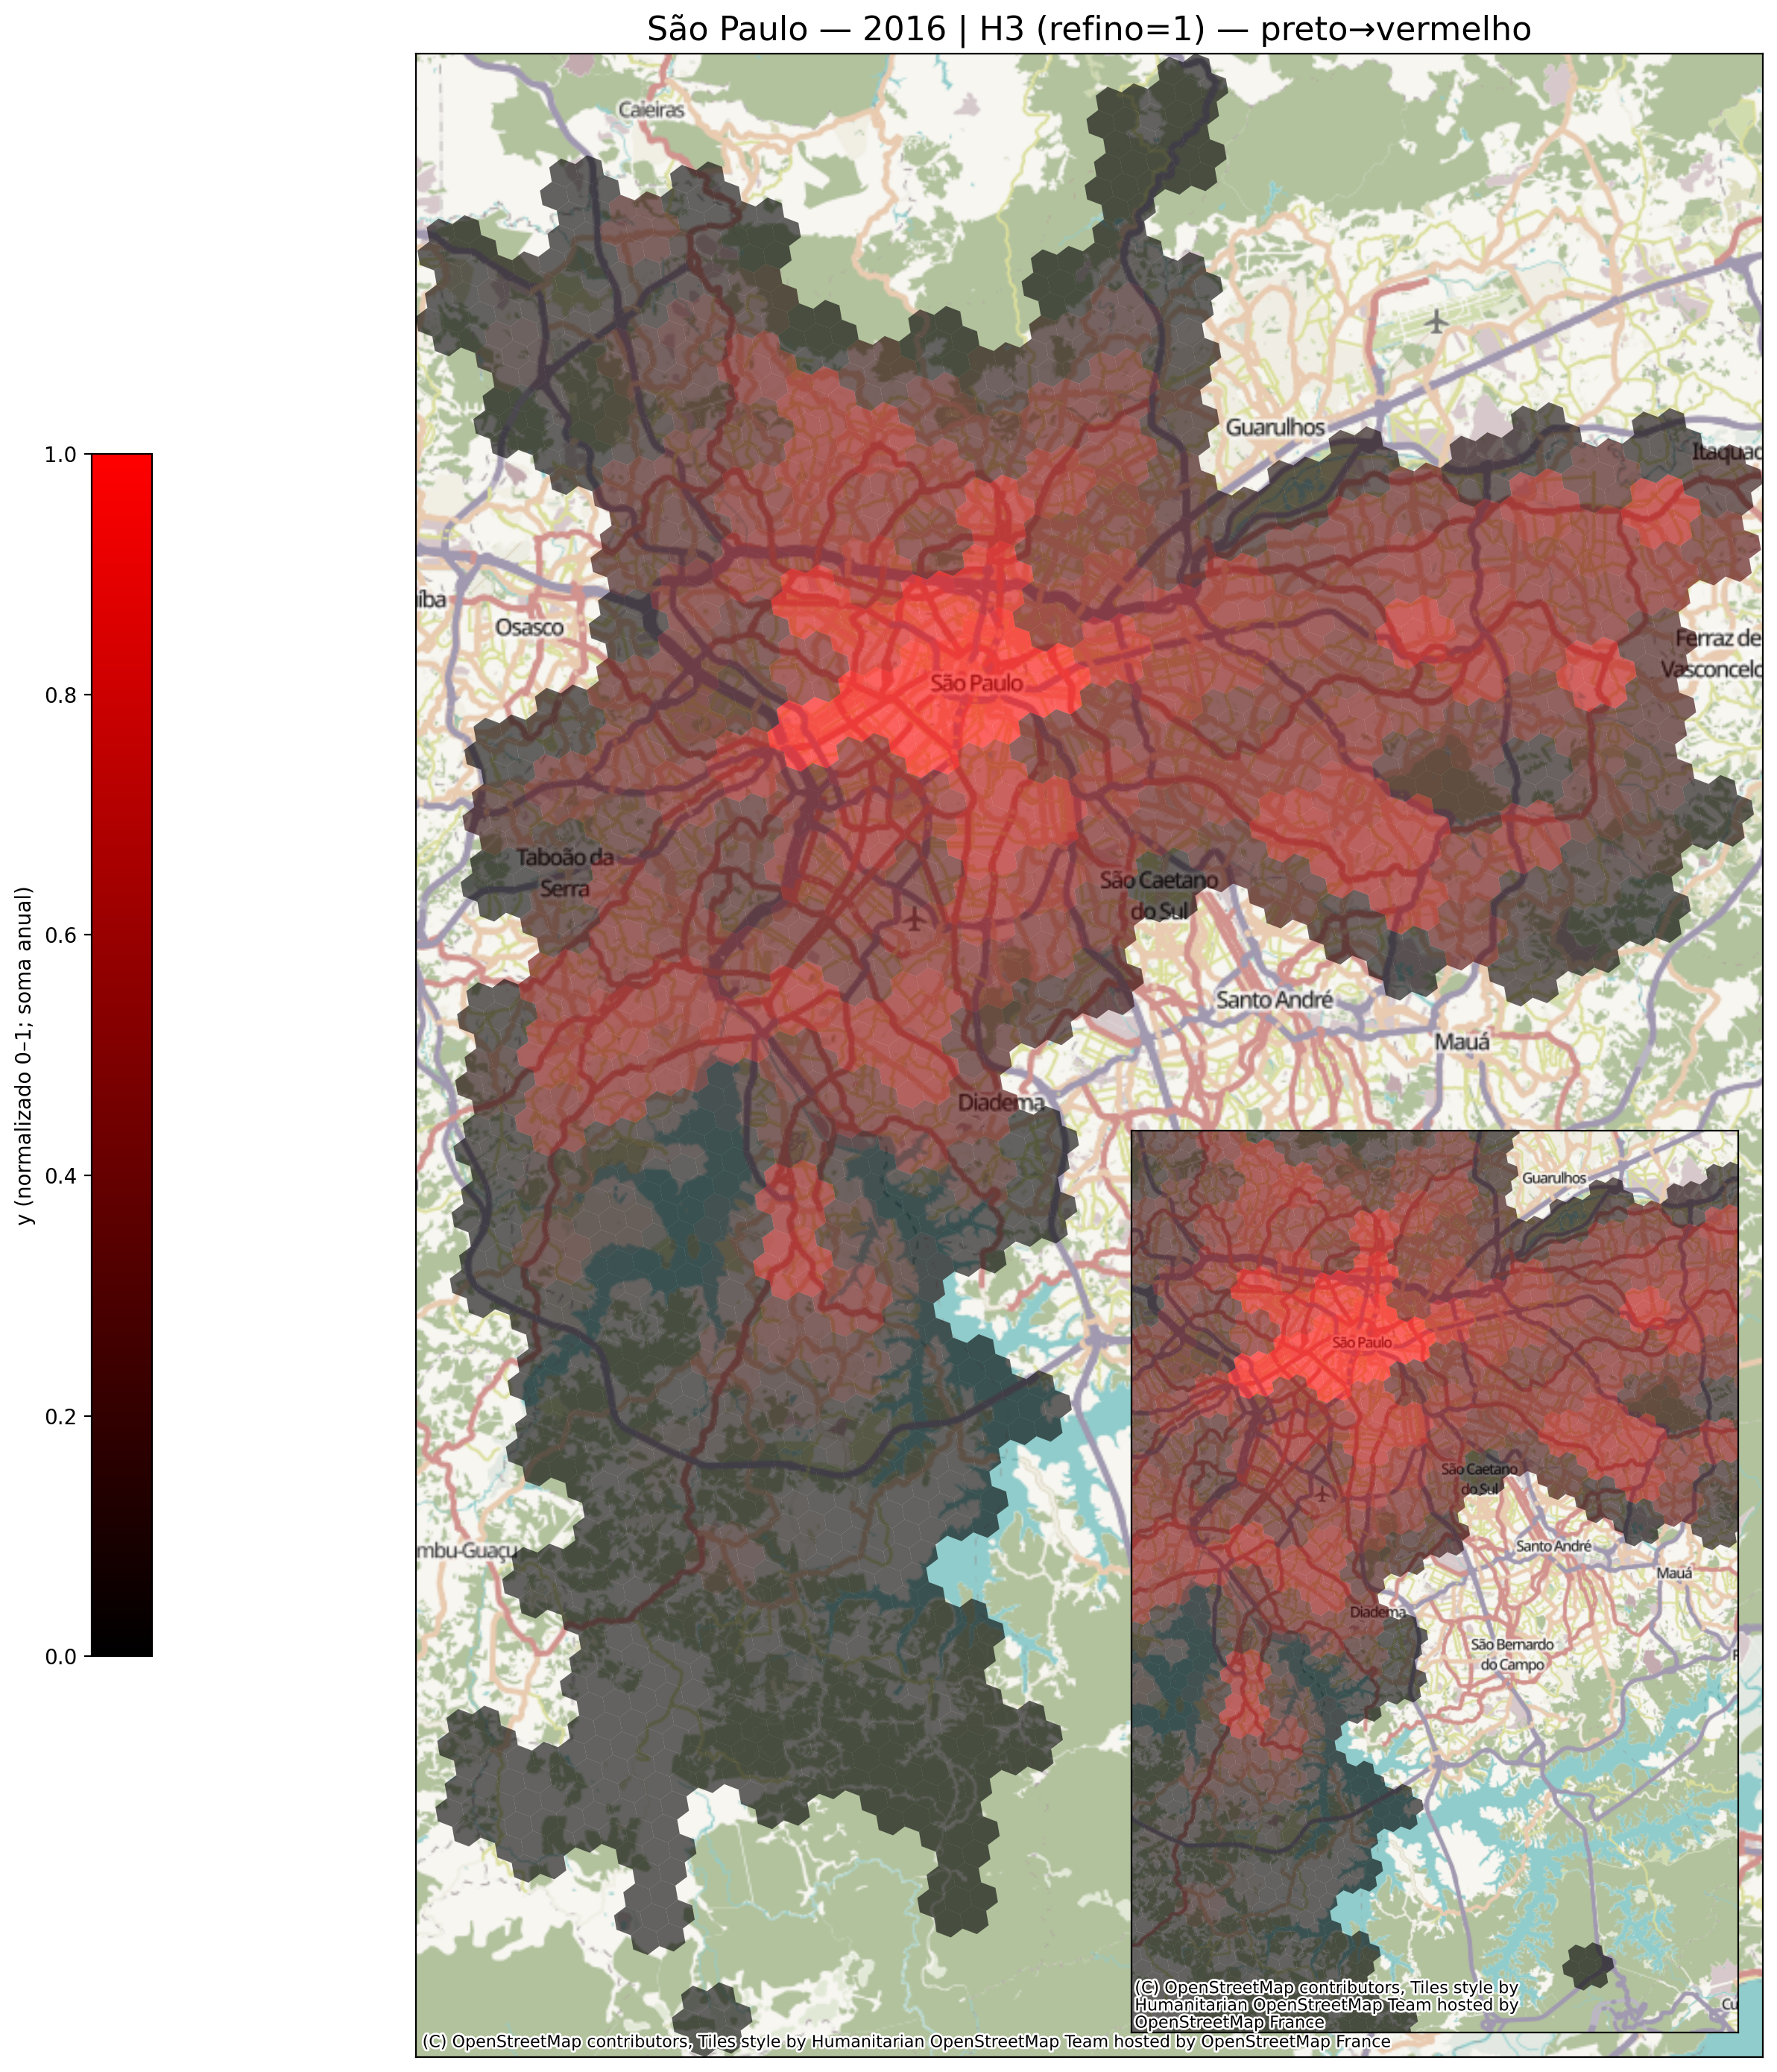

In [16]:
# ============================
# CÉLULA | Mapa H3 — 2016 sobre basemap (São Paulo)
# - Agrega 2016 (y: soma; y_norm: média)
# - Hexágonos refinados (somente visual)
# - Gradiente PRETO → VERMELHO
# - Basemap via contextily (EPSG:3857)
# Requisitos: df_panel, h3, pandas, numpy, matplotlib
# Opcionais: geopandas, shapely, contextily, saop/amsp (GeoDataFrames de limites)
# ============================

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
    from shapely.geometry import Polygon
except Exception:
    gpd = None
    Polygon = None

try:
    import contextily as ctx
except Exception:
    ctx = None

# ----------------------------
# Parâmetros
# ----------------------------
COLOR_METRIC = "y"               # "y" (contagem) ou "y_norm" (0–1)
Y_CLIP_QUANTILES = (0.02, 0.98)
FIGSIZE = (18, 14)
DPI = 200

# Refino visual (filhos H3)
VIS_RES_OFFSET = 1
MAX_PLOT_CELLS = 200_000

# Ano alvo
YEAR = 2016
YEAR_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
YEAR_END_EXCL = pd.Timestamp(f"{YEAR+1}-01-01 00:00:00")

# ----------------------------
# Verificações
# ----------------------------
if "df_panel" not in globals() or df_panel is None or df_panel.empty:
    raise RuntimeError("df_panel não encontrado/vazio. Gere-o na Célula #8.")
if "h3" not in globals():
    import h3
if COLOR_METRIC not in df_panel.columns:
    raise RuntimeError(f"Métrica '{COLOR_METRIC}' não existe em df_panel ({list(df_panel.columns)[:10]}...).")

_series = df_panel["period_start"]
if hasattr(_series.dt, "tz") and _series.dt.tz is not None:
    tz = _series.dt.tz
    YEAR_START = YEAR_START.tz_localize(tz) if YEAR_START.tzinfo is None else YEAR_START.tz_convert(tz)
    YEAR_END_EXCL = YEAR_END_EXCL.tz_localize(tz) if YEAR_END_EXCL.tzinfo is None else YEAR_END_EXCL.tz_convert(tz)

# ----------------------------
# Filtro 2016 e agregação
# ----------------------------
mask = (_series >= YEAR_START) & (_series < YEAR_END_EXCL)
subset_all = df_panel.loc[mask].copy()
if subset_all.empty:
    raise RuntimeError(f"Não há linhas em df_panel para o ano de {YEAR}.")

if COLOR_METRIC == "y":
    agg = subset_all.groupby("cell_id", as_index=False)["y"].sum()
    values = agg["y"].astype(float).to_numpy()
elif COLOR_METRIC == "y_norm":
    agg = subset_all.groupby("cell_id", as_index=False)["y_norm"].mean()
    values = agg["y_norm"].astype(float).to_numpy()
else:
    raise RuntimeError("COLOR_METRIC deve ser 'y' ou 'y_norm'.")

# Normalização
if COLOR_METRIC == "y":
    lo, hi = np.quantile(values, Y_CLIP_QUANTILES)
    if hi <= lo:
        lo, hi = values.min(), values.max()
    lo = float(lo); hi = float(hi)
    norm_vals = np.clip((values - lo) / (hi - lo + 1e-12), 0, 1) if hi > lo else np.zeros_like(values)
else:
    lo, hi = 0.0, 1.0
    norm_vals = np.clip(values, 0, 1)

agg["_norm"] = norm_vals
subset = agg.rename(columns={COLOR_METRIC: COLOR_METRIC})

# ----------------------------
# Helpers H3
# ----------------------------
def _get_res(cell_id: str) -> int:
    if hasattr(h3, "get_resolution"):
        return h3.get_resolution(cell_id)
    elif hasattr(h3, "h3_get_resolution"):
        return h3.h3_get_resolution(cell_id)
    raise RuntimeError("Binding H3 sem get_resolution/h3_get_resolution.")

def _children(cell_id: str, target_res: int):
    if hasattr(h3, "cell_to_children"):
        return h3.cell_to_children(cell_id, target_res)
    elif hasattr(h3, "h3_to_children"):
        return h3.h3_to_children(cell_id, target_res)
    else:
        raise RuntimeError("Binding H3 sem cell_to_children/h3_to_children.")

def _cell_to_boundary_latlon(cell_id: str):
    def _normalize(boundary):
        out = []
        for p in boundary:
            if isinstance(p, dict):
                lat = p.get("lat") or p.get("latitude") or p.get("y") or p.get("lat_deg")
                lon = p.get("lng") or p.get("lon") or p.get("longitude") or p.get("x") or p.get("lng_deg")
                out.append((float(lat), float(lon)))
            else:
                lat, lon = p
                out.append((float(lat), float(lon)))
        return out

    if hasattr(h3, "cell_to_boundary"):
        try:
            b = h3.cell_to_boundary(cell_id, geo_json=True)
        except TypeError:
            b = h3.cell_to_boundary(cell_id)
        return _normalize(b)
    elif hasattr(h3, "h3_to_geo_boundary"):
        try:
            b = h3.h3_to_geo_boundary(cell_id, geo_json=True)
        except TypeError:
            b = h3.h3_to_geo_boundary(cell_id)
        return _normalize(b)
    else:
        raise RuntimeError("Binding H3 sem cell_to_boundary/h3_to_geo_boundary.")

# ----------------------------
# Refino visual
# ----------------------------
if VIS_RES_OFFSET > 0:
    base_res = _get_res(subset["cell_id"].iloc[0])
    target_res = base_res + int(VIS_RES_OFFSET)
    rows = []
    for _, row in subset.iterrows():
        for ch in _children(row["cell_id"], target_res):
            rows.append((ch, float(row["_norm"])))
    vis_df = pd.DataFrame(rows, columns=["cell_id", "_norm"])
    if len(vis_df) > MAX_PLOT_CELLS:
        warnings.warn(
            f"Número de células para plot excede {MAX_PLOT_CELLS:,}. Amostrando para evitar travamentos."
        )
        vis_df = vis_df.sample(MAX_PLOT_CELLS, random_state=42)
else:
    vis_df = subset[["cell_id", "_norm"]].copy()

# ----------------------------
# Construção dos polígonos e reprojeção para 3857
# ----------------------------
import matplotlib.colors as mcolors
black_red = mcolors.LinearSegmentedColormap.from_list("black_red", ["#000000", "#FF0000"])

if gpd is None or Polygon is None:
    raise RuntimeError("Para sobrepor em basemap, instale geopandas e shapely.")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
geoms = []
for cid in vis_df["cell_id"]:
    pts_latlon = _cell_to_boundary_latlon(cid)
    geoms.append(Polygon([(lon, lat) for (lat, lon) in pts_latlon]))
gdf = gpd.GeoDataFrame(vis_df.copy(), geometry=geoms, crs="EPSG:4326")
gdf3857 = gdf.to_crs(epsg=3857)

# Limites administrativos opcionais (se existirem como GeoDataFrames no ambiente)
saop3857 = amsp3857 = None
if "saop" in globals() and isinstance(globals()["saop"], type(gdf)):
    saop3857 = saop.to_crs(epsg=3857)
if "amsp" in globals() and isinstance(globals()["amsp"], type(gdf)):
    amsp3857 = amsp.to_crs(epsg=3857)

# ----------------------------
# Plot com basemap + inset
# ----------------------------
fig, ax = plt.subplots(1, figsize=FIGSIZE, dpi=DPI)

# (1) Limites (se disponíveis)
if amsp3857 is not None:
    amsp3857.boundary.plot(ax=ax, color="black", lw=1, alpha=0.7)
if saop3857 is not None:
    saop3857.boundary.plot(ax=ax, color="black", lw=1, alpha=0.9)

# (2) Hexágonos
gdf3857.plot(
    ax=ax,
    column="_norm",
    cmap=black_red,
    vmin=0, vmax=1,
    alpha=0.6,
    linewidth=0.0,
    legend=True,
    legend_kwds={
        "location": "left",
        "label": ("y (normalizado 0–1; soma anual)" if COLOR_METRIC == "y" else "y_norm (média anual)"),
        "shrink": 0.6
    },
)

# (3) Ajuste da janela aos dados antes do basemap
xmin, ymin, xmax, ymax = gdf3857.total_bounds
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

# (4) Basemap
if ctx is not None:
    try:
        ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite, crs="EPSG:3857")
    except Exception:
        # fallback para OSM padrão
        ctx.add_basemap(ax, crs="EPSG:3857")
else:
    warnings.warn("contextily não instalado; o basemap não será exibido.")

# Inset automático: usa envelope de 'saop' se existir; senão, usa 60% do envelope dos dados
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="45%", height="45%", loc="lower right", borderpad=1.2)

if saop3857 is not None:
    xs, ys, Xe, Ye = saop3857.total_bounds
else:
    xs, ys, Xe, Ye = gdf3857.total_bounds
dx, dy = Xe - xs, Ye - ys
pad = 0.15  # 15% de margem
axins.set_xlim(xs + pad*dx, Xe - pad*dx)
axins.set_ylim(ys + pad*dy, Ye - pad*dy)

# Repetimos o desenho no inset
if amsp3857 is not None:
    amsp3857.boundary.plot(ax=axins, color="black", lw=1, alpha=0.7)
if saop3857 is not None:
    saop3857.boundary.plot(ax=axins, color="black", lw=1, alpha=0.9)

gdf3857.plot(
    ax=axins,
    column="_norm",
    cmap=black_red,
    vmin=0, vmax=1,
    alpha=0.6,
    linewidth=0.0,
)

if ctx is not None:
    try:
        ctx.add_basemap(axins, source=ctx.providers.Stamen.TonerLite, crs="EPSG:3857")
    except Exception:
        ctx.add_basemap(axins, crs="EPSG:3857")

# Acabamento
ax.set_title(f"São Paulo — {YEAR} | H3 (refino={VIS_RES_OFFSET}) — preto→vermelho", fontsize=16)
for a in (ax, axins):
    a.set_xticklabels([]); a.set_yticklabels([])
    a.tick_params(length=0)
ax.margins(0)
fig.tight_layout()
# Salvar, se desejar:
#plt.savefig("sp_h3_2016.png", dpi=DPI, bbox_inches="tight")
plt.show()


In [17]:
# ====================================================================================
# CÉLULA #10 | Features Essenciais (lags e médias temporais)
# Objetivo:
#   - Criar features mínimas para o modelo:
#       1) Lags temporais por célula (y_lag_1) e média móvel (y_rol_3), SEM olhar o futuro.
#       2) Atributos temporais diretos (mês, semana ISO, ano, dia da semana).
#       3) Média do y_lag_1 dos vizinhos H3 (anel=1) corretamente ALINHADA no mesmo período.
#   - Entregar df_panel pronto para modelagem.
#
# Dependências:
#   - df_panel (saída da CÉLULA #8 — painel célula×período densificado)
#   - h3 (para vizinhança)
# ====================================================================================

if "df_panel" not in globals() or df_panel is None or df_panel.empty:
    raise RuntimeError("df_panel não encontrado. Execute a CÉLULA #8 antes.")

# --- 1) Ordenação e coerência temporal ---
df_panel = df_panel.sort_values(["cell_id", "period_start"]).reset_index(drop=True)

# --- 2) Lags temporais por célula ---
print(">>> Criando lags e médias móveis...")

def criar_lags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Para cada célula:
      - y_lag_1  = y no período anterior
      - y_rol_3  = média móvel de 3 períodos, calculada sobre y e deslocada 1 (não olha o presente/futuro)
    """
    df = df.copy()
    df["y_lag_1"] = df["y"].shift(1)
    df["y_rol_3"] = df["y"].rolling(window=3, min_periods=1).mean().shift(1)
    return df

# Nota de desempenho: groupby.apply é suficiente aqui; em volumes muito grandes, usar transform com
# agrupamento pré-ordenado pode reduzir overhead de função Python.
df_panel = df_panel.groupby("cell_id", group_keys=False).apply(criar_lags)

# Lags iniciais (primeira linha de cada célula) -> 0
df_panel[["y_lag_1", "y_rol_3"]] = df_panel[["y_lag_1", "y_rol_3"]].fillna(0)

# --- 3) Features temporais básicas ---
print(">>> Adicionando atributos temporais diretos...")
df_panel["month"] = df_panel["period_start"].dt.month
df_panel["weekofyear"] = df_panel["period_start"].dt.isocalendar().week.astype(int)
df_panel["year"] = df_panel["period_start"].dt.year
df_panel["dow"] = df_panel["period_start"].dt.dayofweek  # 0=segunda, 6=domingo

# --- 4) Média dos vizinhos H3 (anel=1), alinhada no mesmo período ---
print(">>> Calculando y_lag_1 dos vizinhos (anel=1), alinhado no mesmo período...")

def _h3_neighbors(cell_id: str, ring_size: int = 1) -> set:
    """
    Retorna o conjunto de vizinhos H3 de 'cell_id' no anel solicitado.
    Compatível com H3 v3 (k_ring) e v4+ (grid_disk).
    """
    if hasattr(h3, "grid_disk"):  # H3 v4+
        return set(h3.grid_disk(cell_id, ring_size)) - {cell_id}
    if hasattr(h3, "k_ring"):     # H3 v3.x
        return set(h3.k_ring(cell_id, ring_size)) - {cell_id}
    raise RuntimeError("Nenhuma função de vizinhança H3 ('grid_disk' ou 'k_ring') disponível.")

# Mapeia cada célula aos seus vizinhos (anel=1)
unique_cells = df_panel["cell_id"].unique()
neighbors_map = {c: list(_h3_neighbors(c, 1)) for c in unique_cells}

# Referência temporal dos LAGS dos vizinhos:
# NÃO deslocamos a data. Para cada (c, t), queremos a média de y_{t-1} dos vizinhos.
lag_ref = df_panel[["cell_id", "period_start", "y_lag_1"]].copy()

# Expande relação célula → vizinho (linhas: [cell_id, neighbor_id])
rows = []
for c, neighs in neighbors_map.items():
    for n in neighs:
        rows.append((c, n))
neighbor_df = pd.DataFrame(rows, columns=["cell_id", "neighbor_id"])

# Junta lag_ref dos vizinhos no MESMO período (alinhamento correto, sem assumir granularidade semanal)
lag_neighbors = neighbor_df.merge(
    lag_ref,
    left_on="neighbor_id", right_on="cell_id",
    how="left",
    suffixes=("", "_src")
)[["cell_id", "period_start", "y_lag_1"]]

# Média do y_lag_1 dos vizinhos por célula e período
y_lag_neighbors_mean = (
    lag_neighbors.groupby(["cell_id", "period_start"])["y_lag_1"]
    .mean()
    .reset_index()
    .rename(columns={"y_lag_1": "y_lag_1_vizinhos"})
)

# --- MERGE FINAL (robusto a reexecuções) ---

# 1) Remove resíduos de execuções anteriores
for _c in ["y_lag_1_vizinhos", "y_lag_1_vizinhos_x", "y_lag_1_vizinhos_y"]:
    if _c in df_panel.columns:
        df_panel.drop(columns=_c, inplace=True)

# 2) Merge (one-to-one na chave resultante)
df_panel = df_panel.merge(
    y_lag_neighbors_mean,
    on=["cell_id", "period_start"],
    how="left",
    suffixes=("", "_nb"),
    validate="one_to_one"
)

# 3) Padroniza nome se vier com sufixo
if "y_lag_1_vizinhos_nb" in df_panel.columns and "y_lag_1_vizinhos" not in df_panel.columns:
    df_panel.rename(columns={"y_lag_1_vizinhos_nb": "y_lag_1_vizinhos"}, inplace=True)

# 4) Ausentes -> 0 (células de borda sem vizinhos observados no período)
df_panel["y_lag_1_vizinhos"] = df_panel["y_lag_1_vizinhos"].fillna(0).astype(float)

# --- 5) Higiene final ---
# Garantir ausência de NaNs residuais após a criação das features.
df_panel.fillna(0, inplace=True)

# --- 6) Relatório resumido ---
print("\n=== RESUMO FEATURES ESSENCIAIS ===")
print(f"Linhas totais: {len(df_panel):,}")
print(f"Colunas: {df_panel.shape[1]} → {list(df_panel.columns)}")

print("\nAmostra (5 linhas):")
try:
    display(df_panel.head())
except Exception:
    print(df_panel.head())

print("\nEstatísticas das principais variáveis:")
try:
    display(df_panel[["y", "y_norm", "y_lag_1", "y_rol_3", "y_lag_1_vizinhos"]].describe())
except Exception:
    print(df_panel[["y", "y_norm", "y_lag_1", "y_rol_3", "y_lag_1_vizinhos"]].describe())

# Indicador de dispersão de vizinhos
n_viz_zero = (df_panel["y_lag_1_vizinhos"] == 0).sum()
print(f"\nLinhas com y_lag_1_vizinhos=0: {n_viz_zero:,} ({n_viz_zero / len(df_panel) * 100:.2f}%)")

# DataFrame final pronto para modelagem:
# df_features_ready = df_panel.copy()


>>> Criando lags e médias móveis...
>>> Adicionando atributos temporais diretos...
>>> Calculando y_lag_1 dos vizinhos (anel=1), alinhado no mesmo período...

=== RESUMO FEATURES ESSENCIAIS ===
Linhas totais: 902,857
Colunas: 14 → ['cell_id', 'period_start', 'y', 'crimes_unicos', 'tipos_locais', 'cobertura_dominante', 'y_norm', 'y_lag_1', 'y_rol_3', 'month', 'weekofyear', 'year', 'dow', 'y_lag_1_vizinhos']

Amostra (5 linhas):


,cell_id,period_start,y,crimes_unicos,tipos_locais,cobertura_dominante,y_norm,y_lag_1,y_rol_3,month,weekofyear,year,dow,y_lag_1_vizinhos
0,87a810000ffffff,2010-09-15 00:00:00-03:00,1,1,1,subcoberta,1.0,0.0,0.000000,9,37,2010,2,0.0
1,87a810000ffffff,2010-09-16 00:00:00-03:00,0,0,0,subcoberta,0.0,1.0,1.000000,9,37,2010,3,0.0
2,87a810000ffffff,2010-09-17 00:00:00-03:00,0,0,0,subcoberta,0.0,0.0,0.500000,9,37,2010,4,0.0
3,87a810000ffffff,2010-09-18 00:00:00-03:00,0,0,0,subcoberta,0.0,0.0,0.333333,9,37,2010,5,0.0
4,87a810000ffffff,2010-09-19 00:00:00-03:00,0,0,0,subcoberta,0.0,0.0,0.000000,9,37,2010,6,0.0



Estatísticas das principais variáveis:


,y,y_norm,y_lag_1,y_rol_3,y_lag_1_vizinhos
count,902857.000000,902857.000000,902857.000000,902857.000000,902857.000000
mean,1.731234,0.053698,1.729474,1.728810,1.775716
std,3.629233,0.111099,3.628157,3.384000,2.761163
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.333333
75%,2.000000,0.071429,2.000000,2.666667,2.833333
max,215.000000,1.000000,215.000000,149.333333,61.166667



Linhas com y_lag_1_vizinhos=0: 395,363 (43.79%)


In [18]:
"""
PrePol — Split Temporal, Baselines e Treino Inicial (RandomForest)
Propósito: 
- Realizar split temporal (treino=2013–2015; teste=2016),
- Construir baselines em escala y_norm (persistência e média móvel defasada),
- Treinar RandomForest em features essenciais,
- Avaliar com MAE, RMSE, R² e correlação de Pearson, com proteções simples.

Pré-condições:
- df_panel existe, não vazio, com colunas: 
  ['cell_id','period_start','y_norm','y_lag_1','y_rol_3','y_lag_1_vizinhos','month','weekofyear','year'].
- y_norm ∈ [0,1] (verificado e avisado se fora).

Complexidade: O(n) no número de linhas; adequado a notebook protótipo.
"""

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import numpy as np

# --- Verificação de df_panel ---
if "df_panel" not in globals() or df_panel is None or df_panel.empty:
    raise RuntimeError("df_panel não encontrado. Execute as células anteriores.")

# --- 0) Preparos: ordenar e gerar baselines normalizadas (sem vazamento) ---
# Baselines na MESMA escala de y_norm. Usamos shift(1) para excluir o período corrente.
df_panel = df_panel.sort_values(["cell_id", "period_start"]).reset_index(drop=True)

# Defasagem 1 de y_norm
df_panel["y_norm_lag_1"] = (
    df_panel.groupby("cell_id", group_keys=False)["y_norm"].shift(1).fillna(0.0)
)

# Média móvel(3) defasada: média das 3 observações anteriores (inclui min_periods=1); equivalente a rolling após shift
df_panel["y_norm_rol_3"] = (
    df_panel.groupby("cell_id", group_keys=False)["y_norm"]
            .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).mean())
            .fillna(0.0)
)

# --- 1) Split temporal ---
print(">>> Split temporal (treino=2013–2015, teste=2016)")

train = df_panel[df_panel["year"].between(2013, 2015)].copy()
test  = df_panel[df_panel["year"] == 2016].copy()

X_cols = ["y_lag_1", "y_rol_3", "y_lag_1_vizinhos", "month", "weekofyear", "year"]
y_col = "y_norm"

# 1.0) Assert de existência de colunas requeridas (evita treino silencioso com features faltantes)
missing = [c for c in (X_cols + [y_col]) if c not in df_panel.columns]
if missing:
    raise RuntimeError(f"Colunas faltantes para treino/teste: {missing}")

print(f"Período treino: {train['period_start'].min()} → {train['period_start'].max()}")
print(f"Período teste : {test['period_start'].min()} → {test['period_start'].max()}")

# 1.1) Saneamento: remover linhas com NaN nas colunas requeridas (inclui baselines)
req_cols = X_cols + [y_col, "y_norm_lag_1", "y_norm_rol_3"]
mask_train = ~train[req_cols].isna().any(axis=1)
mask_test  = ~test[req_cols].isna().any(axis=1)

n_drop_train = int((~mask_train).sum())
n_drop_test  = int((~mask_test).sum())
if n_drop_train:
    print(f"[AVISO] Removendo {n_drop_train:,} linhas com NaN no TREINO.")
    train = train.loc[mask_train].copy()
if n_drop_test:
    print(f"[AVISO] Removendo {n_drop_test:,} linhas com NaN no TESTE.")
    test = test.loc[mask_test].copy()

if train.empty or test.empty:
    raise RuntimeError("Após remover NaNs, treino ou teste ficou vazio. Verifique a engenharia de features.")

X_train, y_train = train[X_cols], train[y_col].astype(float).to_numpy()
X_test,  y_true  = test[X_cols],  test[y_col].astype(float).to_numpy()

print(f"Tamanho do treino: {len(X_train):,} | teste: {len(X_test):,}")

# 1.2) Checagem rápida da faixa do alvo normalizado
y_min, y_max = float(np.min(y_train)), float(np.max(y_train))
if (y_min < -1e-6) or (y_max > 1 + 1e-6):
    print(f"[AVISO] y_norm fora de [0,1] no treino: min={y_min:.4f}, max={y_max:.4f}")

# --- 2) Baselines (escala y_norm) ---
print("\n>>> Baselines (persistência e média móvel defasada)")
y_pred_persist = test["y_norm_lag_1"].to_numpy(dtype=float)
y_pred_roll    = test["y_norm_rol_3"].to_numpy(dtype=float)

def _rmse(y_t: np.ndarray, y_p: np.ndarray) -> float:
    return float(mean_squared_error(y_t, y_p, squared=False))

def _pearson_safe(a: np.ndarray, b: np.ndarray) -> float:
    if np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return np.nan
    try:
        return float(pearsonr(a, b)[0])
    except Exception:
        return float(np.corrcoef(a, b)[0, 1])

def _r2_safe(y_t: np.ndarray, y_p: np.ndarray) -> float:
    return float(r2_score(y_t, y_p)) if np.nanstd(y_t) > 0 else np.nan

def _safe_eval(name: str, y_t: np.ndarray, y_p: np.ndarray) -> None:
    mae  = float(mean_absolute_error(y_t, y_p))
    rmse = float(_rmse(y_t, y_p))
    r2   = _r2_safe(y_t, y_p)
    rho  = _pearson_safe(y_t, y_p)
    r2_s  = f"{r2:.4f}" if np.isfinite(r2) else "NA"
    rho_s = f"{rho:.4f}" if np.isfinite(rho) else "NA"
    print(f"{name:<15} | MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2_s} | ρ={rho_s} | n={y_t.shape[0]}")

_safe_eval("Persistência", y_true, y_pred_persist)
_safe_eval("Média móvel",  y_true, y_pred_roll)

# --- 3) RandomForest inicial ---
print("\n>>> Treinando RandomForestRegressor (features essenciais)")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    n_jobs=-1,
    random_state=RANDOM_STATE if "RANDOM_STATE" in globals() else 42,
    oob_score=False
)
rf.fit(X_train, y_train)

# Predição no teste (alvo em [0,1])
y_pred_rf = np.clip(rf.predict(X_test), 0.0, 1.0)

# --- 4) Avaliação do modelo ---
mae_rf  = float(mean_absolute_error(y_true, y_pred_rf))
rmse_rf = float(_rmse(y_true, y_pred_rf))
r2_rf   = _r2_safe(y_true, y_pred_rf)
rho_rf  = _pearson_safe(y_true, y_pred_rf)

print("\n=== RESULTADOS RANDOMFOREST ===")
print(f"MAE : {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²  : {r2_rf:.4f}" if np.isfinite(r2_rf) else "R²  : NA")
print(f"ρ   : {rho_rf:.4f}" if np.isfinite(rho_rf) else "ρ   : NA")

# Importâncias das features (diagnóstico)
if hasattr(rf, "feature_importances_") and len(X_cols) == len(rf.feature_importances_):
    importances = sorted(zip(X_cols, rf.feature_importances_), key=lambda x: -x[1])
    print("\nImportâncias das features:")
    for fname, imp in importances:
        print(f" - {fname:<20}: {imp:.4f}")
else:
    print("\nImportância das features não disponível ou incompatível.")


>>> Split temporal (treino=2013–2015, teste=2016)
Período treino: 2013-01-01 00:00:00-03:00 → 2015-12-31 00:00:00-03:00
Período teste : 2016-01-01 00:00:00-03:00 → 2016-12-31 00:00:00-03:00
Tamanho do treino: 405,890 | teste: 107,593

>>> Baselines (persistência e média móvel defasada)
Persistência    | MAE=0.0402 | RMSE=0.0693 | R²=0.6076 | ρ=0.8041 | n=107593
Média móvel     | MAE=0.0360 | RMSE=0.0613 | R²=0.6933 | ρ=0.8378 | n=107593

>>> Treinando RandomForestRegressor (features essenciais)

=== RESULTADOS RANDOMFOREST ===
MAE : 0.0548
RMSE: 0.0847
R²  : 0.4137
ρ   : 0.8010

Importâncias das features:
 - y_rol_3             : 0.9247
 - y_lag_1_vizinhos    : 0.0345
 - weekofyear          : 0.0180
 - y_lag_1             : 0.0116
 - year                : 0.0070
 - month               : 0.0042


In [19]:
"""
PrePol — CÉLULA 8 | Enriquecimento Temporal e Espacial
Propósito:
- Criar memória temporal adicional (lags 2 e 3) e EMA defasada (sem vazamento).
- Difundir informação espacial via vizinhança H3 (anel 1, anel 2 e média ponderada por distância).
- Incluir harmônicos sazonais suaves com base em semana do ano.

Pré-condições (falha cedo se ausentes):
- df_panel contém: ['cell_id','period_start','y','y_lag_1','weekofyear'].
- Função global _h3_neighbors(cell_id, ring_size) definida.

Notas:
- Todas as novas colunas são regeneradas de forma idempotente (primeiro removidas se existirem).
- Agregações espaciais usam y_lag_1 do vizinho no MESMO período (evita vazamento temporal).
"""

import numpy as np
import pandas as pd

# --- Verificações iniciais ---
if "df_panel" not in globals() or df_panel is None or df_panel.empty:
    raise RuntimeError("df_panel não encontrado. Execute as etapas anteriores.")
if "_h3_neighbors" not in globals():
    raise RuntimeError("_h3_neighbors não está definido. Execute a célula correspondente.")

req_cols = ["cell_id", "period_start", "y", "y_lag_1", "weekofyear"]
missing = [c for c in req_cols if c not in df_panel.columns]
if missing:
    raise RuntimeError(f"Colunas obrigatórias ausentes em df_panel: {missing}")

print(">>> Iniciando enriquecimento temporal e espacial...")

# Ordenação canônica por célula-tempo
df_panel = df_panel.sort_values(["cell_id", "period_start"]).reset_index(drop=True)

# Idempotência: remover colunas derivadas (se existirem)
cols_to_refresh = [
    "y_lag_2", "y_lag_3", "y_ema_3",
    "y_lag_1_vizinhos", "y_lag_1_vizinhos_ring2", "y_lag_1_vizinhos_pesado",
    "sin_woy", "cos_woy", "sin2_woy", "cos2_woy",
]
to_drop = [c for c in cols_to_refresh if c in df_panel.columns]
if to_drop:
    df_panel = df_panel.drop(columns=to_drop)

# ------------------------------
# 1) Lags temporais adicionais
# ------------------------------
print(" - Criando y_lag_2 e y_lag_3 (memória temporal adicional)")
df_panel["y_lag_2"] = df_panel.groupby("cell_id", group_keys=False)["y"].shift(2)
df_panel["y_lag_3"] = df_panel.groupby("cell_id", group_keys=False)["y"].shift(3)

# ---------------------------------------
# 2) Média exponencial suavizada (EMA)
# ---------------------------------------
print(" - Calculando y_ema_3 defasada (alpha=0.5)")
# Observação: '3' no nome é apenas rótulo histórico; EMA usa alpha=0.5 e é sempre defasada por 1 período.
df_panel["y_ema_3"] = (
    df_panel.groupby("cell_id", group_keys=False)["y"]
            .transform(lambda s: s.shift(1).ewm(alpha=0.5, adjust=False).mean())
)

lag_cols = ["y_lag_2", "y_lag_3", "y_ema_3"]
df_panel[lag_cols] = df_panel[lag_cols].fillna(0.0)

# -----------------------------------------
# 3) Vizinhança H3 (anel 1 e 2 + ponderada)
# -----------------------------------------
print(" - Construindo vizinhança (anel=1 e 2) e agregando y_lag_1 dos vizinhos")

unique_cells = df_panel["cell_id"].unique()
neighbor_records = []
for cell_id in unique_cells:
    ring1 = set(_h3_neighbors(cell_id, 1))
    ring2_full = set(_h3_neighbors(cell_id, 2))
    ring2 = ring2_full - ring1 - {cell_id}
    neighbor_records.extend((cell_id, nb, 1) for nb in ring1)
    neighbor_records.extend((cell_id, nb, 2) for nb in ring2)

neighbor_pairs = (
    pd.DataFrame(neighbor_records, columns=["cell_id", "neighbor_id", "distance"])
      .drop_duplicates()
)

# Base de (célula, período) para cruzamentos
base_index = df_panel[["cell_id", "period_start"]].drop_duplicates()

# Fonte: y_lag_1 do vizinho no mesmo período
neighbor_source = (
    df_panel[["cell_id", "period_start", "y_lag_1"]]
      .rename(columns={"cell_id": "neighbor_id", "y_lag_1": "neighbor_value"})
)

def _aggregate_neighbor_mean(pairs_df: pd.DataFrame, output_name: str) -> pd.DataFrame:
    """Média simples de neighbor_value por (cell_id, period_start)."""
    if pairs_df.empty:
        out = base_index.copy()
        out[output_name] = 0.0
        return out
    expanded = base_index.merge(pairs_df[["cell_id", "neighbor_id"]], on="cell_id", how="left").dropna(subset=["neighbor_id"])
    if expanded.empty:
        out = base_index.copy()
        out[output_name] = 0.0
        return out
    neighbor_values = expanded.merge(neighbor_source, on=["neighbor_id", "period_start"], how="left")
    aggregated = (
        neighbor_values.groupby(["cell_id", "period_start"])["neighbor_value"]
                       .mean()
                       .reset_index()
                       .rename(columns={"neighbor_value": output_name})
    )
    return aggregated

def _aggregate_neighbor_weighted(pairs_df: pd.DataFrame, output_name: str) -> pd.DataFrame:
    """Média ponderada por 1/distance (1 para anel1; 1/2 para anel2)."""
    if pairs_df.empty:
        out = base_index.copy()
        out[output_name] = 0.0
        return out
    expanded = base_index.merge(pairs_df, on="cell_id", how="left").dropna(subset=["neighbor_id"])
    if expanded.empty:
        out = base_index.copy()
        out[output_name] = 0.0
        return out
    neighbor_values = expanded.merge(neighbor_source, on=["neighbor_id", "period_start"], how="left")
    neighbor_values["weight"] = 1.0 / neighbor_values["distance"].replace(0, np.nan)
    # Evitar NaN propagando: trate valores ausentes como 0 no produto ponderado
    neighbor_values["weighted_value"] = neighbor_values["neighbor_value"].fillna(0.0) * neighbor_values["weight"]
    aggregated = (
        neighbor_values.groupby(["cell_id", "period_start"])
                       .agg(weighted_sum=("weighted_value", "sum"),
                            weight_sum=("weight", "sum"))
                       .reset_index()
    )
    aggregated[output_name] = np.where(
        aggregated["weight_sum"] > 0,
        aggregated["weighted_sum"] / aggregated["weight_sum"],
        0.0
    )
    return aggregated[["cell_id", "period_start", output_name]]

# Agregações por anel
ring1_pairs = neighbor_pairs[neighbor_pairs["distance"] == 1][["cell_id", "neighbor_id", "distance"]]
ring2_pairs = neighbor_pairs[neighbor_pairs["distance"] == 2][["cell_id", "neighbor_id", "distance"]]

agg_ring1    = _aggregate_neighbor_mean(ring1_pairs, "y_lag_1_vizinhos")
agg_ring2    = _aggregate_neighbor_mean(ring2_pairs, "y_lag_1_vizinhos_ring2")
agg_weighted = _aggregate_neighbor_weighted(neighbor_pairs, "y_lag_1_vizinhos_pesado")

# Merge das novas features
for agg_df in (agg_ring1, agg_ring2, agg_weighted):
    df_panel = df_panel.merge(agg_df, on=["cell_id", "period_start"], how="left")

neighbor_cols = ["y_lag_1_vizinhos", "y_lag_1_vizinhos_ring2", "y_lag_1_vizinhos_pesado"]
df_panel[neighbor_cols] = df_panel[neighbor_cols].fillna(0.0)

# ---------------------------------------
# 4) Harmônicos sazonais (semana do ano)
# ---------------------------------------
print(" - Adicionando harmônicos de semana do ano (sin/cos)")
week = pd.to_numeric(df_panel["weekofyear"], errors="coerce").fillna(0).to_numpy(dtype=float)
df_panel["sin_woy"]  = np.sin(2 * np.pi * week / 52.0)
df_panel["cos_woy"]  = np.cos(2 * np.pi * week / 52.0)
df_panel["sin2_woy"] = np.sin(4 * np.pi * week / 52.0)
df_panel["cos2_woy"] = np.cos(4 * np.pi * week / 52.0)

# -----------------------
# Relatório e sanidade
# -----------------------
new_feature_cols = lag_cols + neighbor_cols + ["sin_woy", "cos_woy", "sin2_woy", "cos2_woy"]
print("=== NOVAS FEATURES CRIADAS ===")
print(new_feature_cols)

missing_counts = df_panel[new_feature_cols].isna().sum()
if missing_counts.any():
    print("[ALERTA] Foram encontrados NaNs nas novas variáveis:")
    print(missing_counts[missing_counts > 0])
else:
    print("Nenhum NaN encontrado nas novas variáveis.")

print("Amostra das novas colunas:")
try:
    display(df_panel[["cell_id", "period_start"] + new_feature_cols].head())
except Exception:
    print(df_panel[["cell_id", "period_start"] + new_feature_cols].head())


>>> Iniciando enriquecimento temporal e espacial...
 - Criando y_lag_2 e y_lag_3 (memória temporal adicional)
 - Calculando y_ema_3 defasada (alpha=0.5)
 - Construindo vizinhança (anel=1 e 2) e agregando y_lag_1 dos vizinhos
 - Adicionando harmônicos de semana do ano (sin/cos)
=== NOVAS FEATURES CRIADAS ===
['y_lag_2', 'y_lag_3', 'y_ema_3', 'y_lag_1_vizinhos', 'y_lag_1_vizinhos_ring2', 'y_lag_1_vizinhos_pesado', 'sin_woy', 'cos_woy', 'sin2_woy', 'cos2_woy']
Nenhum NaN encontrado nas novas variáveis.
Amostra das novas colunas:


,cell_id,period_start,y_lag_2,y_lag_3,y_ema_3,y_lag_1_vizinhos,y_lag_1_vizinhos_ring2,y_lag_1_vizinhos_pesado,sin_woy,cos_woy,sin2_woy,cos2_woy
0,87a810000ffffff,2010-09-15 00:00:00-03:00,0.0,0.0,0.000,0.0,0.000000,0.000000,-0.970942,-0.239316,0.464723,-0.885456
1,87a810000ffffff,2010-09-16 00:00:00-03:00,0.0,0.0,1.000,0.0,0.166667,0.041667,-0.970942,-0.239316,0.464723,-0.885456
2,87a810000ffffff,2010-09-17 00:00:00-03:00,1.0,0.0,0.500,0.0,0.166667,0.041667,-0.970942,-0.239316,0.464723,-0.885456
3,87a810000ffffff,2010-09-18 00:00:00-03:00,0.0,1.0,0.250,0.0,0.000000,0.000000,-0.970942,-0.239316,0.464723,-0.885456
4,87a810000ffffff,2010-09-19 00:00:00-03:00,0.0,0.0,0.125,0.0,0.000000,0.000000,-0.970942,-0.239316,0.464723,-0.885456


In [20]:
# ====================================================================================
# CÉLULA #8.5 | RandomForest (y_norm) com features enriquecidas e métricas adicionais
# Objetivo:
#   - Reaproveitar o painel enriquecido para treinar um RandomForest mais estável.
#   - Avaliar baselines e modelo com métricas adicionais de ranking (Precision/Recall@k).
#   - Correções: (i) remover dependência global de EVAL_GROUPS; (ii) R² seguro;
#                (iii) diagnóstico de normalização de y_norm; (iv) baselines em escala correta.
# ====================================================================================

from typing import Tuple, Dict
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

if "df_panel" not in globals() or df_panel is None or df_panel.empty:
    raise RuntimeError("df_panel não encontrado. Execute as células anteriores.")

print(">>> Preparando dados com features enriquecidas...")

# -----------------------------
# Split temporal e features
# -----------------------------
train_enriched = df_panel[df_panel["year"].between(2013, 2015)].copy()
test_enriched  = df_panel[df_panel["year"] == 2016].copy()
if train_enriched.empty or test_enriched.empty:
    raise RuntimeError("Split temporal resultou em conjuntos vazios. Verifique a coluna 'year' e o recorte.")

feature_cols_enriched = [
    "y_lag_1", "y_lag_2", "y_lag_3", "y_ema_3",
    "y_rol_3",
    "y_lag_1_vizinhos", "y_lag_1_vizinhos_ring2", "y_lag_1_vizinhos_pesado",
    "month", "weekofyear", "year",
    "sin_woy", "cos_woy", "sin2_woy", "cos2_woy"
]

missing_cols = [col for col in feature_cols_enriched if col not in df_panel.columns]
if missing_cols:
    raise RuntimeError(f"As colunas seguintes estão ausentes no df_panel: {missing_cols}")

for frame in (train_enriched, test_enriched):
    frame[feature_cols_enriched] = frame[feature_cols_enriched].fillna(0.0)

if "y_norm" not in df_panel.columns:
    raise RuntimeError("Coluna 'y_norm' ausente no painel.")

# Garantir baselines na MESMA escala do alvo (y_norm): recriar se necessário
df_panel = df_panel.sort_values(["cell_id", "period_start"])
if "y_norm_lag_1" not in df_panel.columns:
    df_panel["y_norm_lag_1"] = df_panel.groupby("cell_id")["y_norm"].shift(1).fillna(0.0)
if "y_norm_rol_3" not in df_panel.columns:
    df_panel["y_norm_rol_3"] = (
        df_panel.groupby("cell_id")["y_norm"].shift(1).rolling(3, min_periods=1).mean().fillna(0.0)
    )

# Rejuntar colunas de baseline corretas aos recortes
train_enriched = train_enriched.merge(
    df_panel[["cell_id","period_start","y_norm_lag_1","y_norm_rol_3"]],
    on=["cell_id","period_start"], how="left"
)
test_enriched = test_enriched.merge(
    df_panel[["cell_id","period_start","y_norm_lag_1","y_norm_rol_3"]],
    on=["cell_id","period_start"], how="left"
).fillna({"y_norm_lag_1":0.0, "y_norm_rol_3":0.0})

X_train_enriched = train_enriched[feature_cols_enriched]
y_train_norm     = train_enriched["y_norm"].astype(float)
X_test_enriched  = test_enriched[feature_cols_enriched]
y_test_norm      = test_enriched["y_norm"].astype(float)

# -----------------------------
# Utilitários de métrica (robustos)
# -----------------------------
def _rmse(y_t: np.ndarray, y_p: np.ndarray) -> float:
    return float(mean_squared_error(y_t, y_p, squared=False))

def _pearson_safe(y_t: np.ndarray, y_p: np.ndarray) -> float:
    if np.nanstd(y_t) == 0 or np.nanstd(y_p) == 0:
        return np.nan
    try:
        return float(pearsonr(y_t, y_p)[0])
    except Exception:
        return float(np.corrcoef(y_t, y_p)[0, 1])

def _r2_safe(y_t: np.ndarray, y_p: np.ndarray) -> float:
    if np.nanstd(y_t) == 0:
        return np.nan
    try:
        return float(r2_score(y_t, y_p))
    except Exception:
        return np.nan

def precision_recall_at_k(
    y_true, y_score, k: float, positive_threshold: float = 0.0, groups: pd.Series = None
) -> Tuple[float, float]:
    """
    Precision/Recall@K.
    - Se 'groups' for fornecido, calcula por grupo (ex.: período) e macro-média.
    - 'k' é fração de linhas selecionadas por grupo (top-k).
    """
    y_true_arr  = np.asarray(y_true, dtype=float)
    y_score_arr = np.asarray(y_score, dtype=float)
    if y_true_arr.size == 0:
        return np.nan, np.nan

    if groups is None:
        n = y_true_arr.shape[0]
        cutoff = max(1, int(np.ceil(n * k)))
        order = np.argsort(-y_score_arr, kind="mergesort")[:cutoff]
        positives_mask = y_true_arr > positive_threshold
        tp = positives_mask[order].sum()
        prec = tp / cutoff
        pos  = positives_mask.sum()
        rec  = (tp / pos) if pos > 0 else np.nan
        return float(prec), (float(rec) if pos > 0 else np.nan)

    groups_arr = pd.Series(groups).to_numpy()
    if groups_arr.shape[0] != y_true_arr.shape[0]:
        raise ValueError("groups deve ter o mesmo comprimento de y_true/y_score")

    precisions, recalls = [], []
    for g in pd.unique(groups_arr):
        mask = (groups_arr == g)
        n_g = int(mask.sum())
        if n_g == 0:
            continue
        cutoff_g = max(1, int(np.ceil(n_g * k)))
        order_local = np.argsort(-y_score_arr[mask], kind="mergesort")[:cutoff_g]
        positives_mask_g = (y_true_arr[mask] > positive_threshold)
        tp_g = positives_mask_g[order_local].sum()
        precisions.append(tp_g / cutoff_g)
        pos_g = int(positives_mask_g.sum())
        recalls.append((tp_g / pos_g) if pos_g > 0 else np.nan)

    prec_macro = float(np.nanmean(precisions)) if len(precisions) > 0 else np.nan
    rec_macro  = float(np.nanmean(np.asarray(recalls, dtype=float))) if len(recalls) > 0 else np.nan
    return prec_macro, rec_macro

def evaluate_regression(
    y_true, y_pred, label: str, *, positive_threshold: float = 0.0, groups: pd.Series
) -> Dict[str, float]:
    """
    Avalia predições com erro (MAE, RMSE), qualidade global (R², ρ)
    e ranking (Precision/Recall@5% e 10%) por período (macro).
    'groups' é OBRIGATÓRIO para ranking por período.
    """
    if groups is None:
        raise ValueError("O argumento 'groups' é obrigatório para avaliar ranking por período.")

    y_t = np.asarray(y_true, dtype=float)
    y_p = np.asarray(y_pred, dtype=float)

    mae  = float(mean_absolute_error(y_t, y_p))
    rmse = _rmse(y_t, y_p)
    r2   = _r2_safe(y_t, y_p)
    rho  = _pearson_safe(y_t, y_p)

    metrics = {"label": label, "MAE": mae, "RMSE": rmse, "R2": r2, "rho": rho}
    for frac, suffix in [(0.05, "5"), (0.10, "10")]:
        prec, rec = precision_recall_at_k(y_t, y_p, frac, positive_threshold, groups=groups)
        metrics[f"precision@{suffix}"] = prec
        metrics[f"recall@{suffix}"]    = rec
    evaluation_registry[label] = metrics
    return metrics

# -----------------------------
# Repositório de métricas
# -----------------------------
evaluation_registry = {}
def _fmt(value):
    return f"{float(value):.4f}" if value is not None and not (isinstance(value, float) and np.isnan(value)) else "NA"

# -----------------------------
# Diagnóstico de normalização de y_norm (apenas alerta)
# -----------------------------
print(">>> Diagnóstico de normalização de y_norm (teste-only min–max por período)...")
if "y" in test_enriched.columns:
    mm_test = test_enriched.groupby("period_start")["y"].agg(y_min="min", y_max="max").reset_index()
    aux = test_enriched[["cell_id", "period_start", "y", "y_norm"]].merge(mm_test, on="period_start", how="left")
    den = (aux["y_max"] - aux["y_min"]).replace(0, np.nan)
    aux["y_norm_test_only"] = (aux["y"] - aux["y_min"]) / den
    aux["y_norm_test_only"] = aux["y_norm_test_only"].fillna(0.0).clip(0.0, 1.0)
    diff = np.nanmean(np.abs(aux["y_norm_test_only"].to_numpy() - aux["y_norm"].to_numpy()))
    if diff > 1e-6:
        print(f"[AVISO] y_norm do TESTE difere da normalização min–max calculada apenas no teste (média |Δ|={diff:.6f}).")
        print("        Isso sugere que y_norm pode ter sido normalizado globalmente (potencial vazamento na normalização).")
else:
    print("[AVISO] Coluna 'y' ausente no teste — diagnóstico de normalização não executado.")

# -----------------------------
# Avaliação: baselines e modelo
# -----------------------------
print(">>> Avaliando baselines (escala correta: y_norm)...")
groups_test = test_enriched["period_start"].reset_index(drop=True)

# Baseline: Persistência (y_norm)
y_pred_persist_norm = test_enriched["y_norm_lag_1_y"].to_numpy(dtype=float).clip(0.0, 1.0)
persist_metrics = evaluate_regression(
    y_test_norm, y_pred_persist_norm, "Baseline Persistência (y_norm)",
    positive_threshold=0.0, groups=groups_test
)
print(f"Persistência | MAE={_fmt(persist_metrics['MAE'])} | RMSE={_fmt(persist_metrics['RMSE'])} | "
      f"R²={_fmt(persist_metrics['R2'])} | ρ={_fmt(persist_metrics['rho'])}")
print(f"             | Precision@5%={_fmt(persist_metrics['precision@5'])} | "
      f"Recall@5%={_fmt(persist_metrics['recall@5'])}")
print(f"             | Precision@10%={_fmt(persist_metrics['precision@10'])} | "
      f"Recall@10%={_fmt(persist_metrics['recall@10'])}")

# Baseline: Média móvel (y_norm)
y_pred_roll_norm = test_enriched["y_norm_rol_3_y"].to_numpy(dtype=float).clip(0.0, 1.0)
roll_metrics = evaluate_regression(
    y_test_norm, y_pred_roll_norm, "Baseline Média Móvel (y_norm)",
    positive_threshold=0.0, groups=groups_test
)
print(f"Média móvel  | MAE={_fmt(roll_metrics['MAE'])} | RMSE={_fmt(roll_metrics['RMSE'])} | "
      f"R²={_fmt(roll_metrics['R2'])} | ρ={_fmt(roll_metrics['rho'])}")
print(f"             | Precision@5%={_fmt(roll_metrics['precision@5'])} | "
      f"Recall@5%={_fmt(roll_metrics['recall@5'])}")
print(f"             | Precision@10%={_fmt(roll_metrics['precision@10'])} | "
      f"Recall@10%={_fmt(roll_metrics['recall@10'])}")

print(">>> Treinando RandomForestRegressor com tuning leve...")

rf_enriched = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_enriched.fit(X_train_enriched, y_train_norm)

y_pred_rf_norm = np.clip(rf_enriched.predict(X_test_enriched), 0.0, 1.0)
rf_metrics = evaluate_regression(
    y_test_norm, y_pred_rf_norm, "RandomForest (y_norm)",
    positive_threshold=0.0, groups=groups_test
)

print(f"RandomForest  | MAE={_fmt(rf_metrics['MAE'])} | RMSE={_fmt(rf_metrics['RMSE'])} | "
      f"R²={_fmt(rf_metrics['R2'])} | ρ={_fmt(rf_metrics['rho'])}")
print(f"             | Precision@5%={_fmt(rf_metrics['precision@5'])} | "
      f"Recall@5%={_fmt(rf_metrics['recall@5'])}")
print(f"             | Precision@10%={_fmt(rf_metrics['precision@10'])} | "
      f"Recall@10%={_fmt(rf_metrics['recall@10'])}")

if hasattr(rf_enriched, "feature_importances_"):
    importances = sorted(zip(feature_cols_enriched, rf_enriched.feature_importances_), key=lambda x: -x[1])
    print("Top 10 importâncias (RandomForest enriquecido):")
    for feat, imp in importances[:10]:
        print(f" - {feat:<30} {imp:.4f}")
else:
    print("Importâncias não disponíveis para o modelo treinado.")

print("[Conclusão CÉLULA #8.5] Métricas registradas em 'evaluation_registry'.")


>>> Preparando dados com features enriquecidas...
>>> Diagnóstico de normalização de y_norm (teste-only min–max por período)...
>>> Avaliando baselines (escala correta: y_norm)...
Persistência | MAE=0.0402 | RMSE=0.0693 | R²=0.6076 | ρ=0.8041
             | Precision@5%=0.9993 | Recall@5%=0.0769
             | Precision@10%=0.9978 | Recall@10%=0.1510
Média móvel  | MAE=0.0360 | RMSE=0.0613 | R²=0.6933 | ρ=0.8378
             | Precision@5%=0.9993 | Recall@5%=0.0769
             | Precision@10%=0.9986 | Recall@10%=0.1511
>>> Treinando RandomForestRegressor com tuning leve...
RandomForest  | MAE=0.0513 | RMSE=0.0776 | R²=0.5082 | ρ=0.8179
             | Precision@5%=0.9993 | Recall@5%=0.0769
             | Precision@10%=0.9985 | Recall@10%=0.1511
Top 10 importâncias (RandomForest enriquecido):
 - y_ema_3                        0.8906
 - y_rol_3                        0.0240
 - y_lag_1_vizinhos_ring2         0.0159
 - y_lag_1_vizinhos               0.0153
 - y_lag_1_vizinhos_pesado       

In [25]:
# ====================================================================================
# CÉLULA #8.5 | RandomForest (y_norm) com features enriquecidas e métricas adicionais
# Objetivo:
#   - Reaproveitar o painel enriquecido para treinar um RandomForest mais estável.
#   - Avaliar baselines e modelo com métricas adicionais de ranking (Precision/Recall@k).
# ====================================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

if "df_panel" not in globals() or df_panel is None or df_panel.empty:
    raise RuntimeError("df_panel não encontrado. Execute as células anteriores.")

print(">>> Preparando dados com features enriquecidas...")

train_enriched = df_panel[df_panel["year"].between(2013, 2015)].copy()
test_enriched = df_panel[df_panel["year"] == 2016].copy()

feature_cols_enriched = [
    "y_lag_1", "y_lag_2", "y_lag_3", "y_ema_3",
    "y_rol_3",
    "y_lag_1_vizinhos", "y_lag_1_vizinhos_ring2", "y_lag_1_vizinhos_pesado",
    "month", "weekofyear", "year",
    "sin_woy", "cos_woy", "sin2_woy", "cos2_woy"
]

missing_cols = [col for col in feature_cols_enriched if col not in df_panel.columns]
if missing_cols:
    raise RuntimeError(f"As colunas seguintes estão ausentes no df_panel: {missing_cols}")

for frame in (train_enriched, test_enriched):
    frame[feature_cols_enriched] = frame[feature_cols_enriched].fillna(0.0)

if "y_norm" not in df_panel.columns:
    raise RuntimeError("Coluna 'y_norm' ausente no painel.")

X_train_enriched = train_enriched[feature_cols_enriched]
y_train_norm = train_enriched["y_norm"]
X_test_enriched = test_enriched[feature_cols_enriched]
y_test_norm = test_enriched["y_norm"]

def precision_recall_at_k(y_true, y_score, k, positive_threshold=0.0):
    y_true_arr = np.asarray(y_true, dtype=float)
    y_score_arr = np.asarray(y_score, dtype=float)
    n = y_true_arr.shape[0]
    if n == 0:
        return np.nan, np.nan
    cutoff = max(1, int(np.ceil(n * k)))
    order = np.argsort(-y_score_arr, kind="mergesort")[:cutoff]
    positives_mask = y_true_arr > positive_threshold
    positives_selected = positives_mask[order].sum()
    precision = positives_selected / cutoff
    total_positives = positives_mask.sum()
    recall = positives_selected / total_positives if total_positives > 0 else np.nan
    return float(precision), (float(recall) if total_positives > 0 else np.nan)

def evaluate_regression(y_true, y_pred, label, positive_threshold=0.0):
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)
    mae = float(mean_absolute_error(y_true_arr, y_pred_arr))
    rmse = float(_rmse(y_true_arr, y_pred_arr))
    r2 = _r2_safe(y_true_arr, y_pred_arr)
    rho = _pearson_safe(y_true_arr, y_pred_arr)
    metrics = {
        "label": label,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "rho": rho,
    }
    for frac, suffix in [(0.05, "5"), (0.10, "10")]:
        prec, rec = precision_recall_at_k(y_true_arr, y_pred_arr, frac, positive_threshold)
        metrics[f"precision@{suffix}"] = prec
        metrics[f"recall@{suffix}"] = rec
    evaluation_registry[label] = metrics
    return metrics

# Repositório de métricas consolidado
evaluation_registry = {}

def _fmt(value):
    return f"{value:.4f}" if value is not None and not np.isnan(value) else "NA"

print(">>> Avaliando baselines renovados...")

y_pred_persist_norm = np.clip(test_enriched["y_lag_1"].to_numpy(dtype=float), 0.0, 1.0)
persist_metrics = evaluate_regression(y_test_norm, y_pred_persist_norm, "Baseline Persistência (y_norm)")
print(f"Persistência | MAE={_fmt(persist_metrics['MAE'])} | RMSE={_fmt(persist_metrics['RMSE'])} | R²={_fmt(persist_metrics['R2'])} | ρ={_fmt(persist_metrics['rho'])}")
print(f"             | Precision@5%={_fmt(persist_metrics['precision@5'])} | Recall@5%={_fmt(persist_metrics['recall@5'])}")
print(f"             | Precision@10%={_fmt(persist_metrics['precision@10'])} | Recall@10%={_fmt(persist_metrics['recall@10'])}")

y_pred_roll_norm = np.clip(test_enriched["y_rol_3"].to_numpy(dtype=float), 0.0, 1.0)
roll_metrics = evaluate_regression(y_test_norm, y_pred_roll_norm, "Baseline Média Móvel (y_norm)")
print(f"Média móvel  | MAE={_fmt(roll_metrics['MAE'])} | RMSE={_fmt(roll_metrics['RMSE'])} | R²={_fmt(roll_metrics['R2'])} | ρ={_fmt(roll_metrics['rho'])}")
print(f"             | Precision@5%={_fmt(roll_metrics['precision@5'])} | Recall@5%={_fmt(roll_metrics['recall@5'])}")
print(f"             | Precision@10%={_fmt(roll_metrics['precision@10'])} | Recall@10%={_fmt(roll_metrics['recall@10'])}")

print(">>> Treinando RandomForestRegressor com tuning leve...")

rf_enriched = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
rf_enriched.fit(X_train_enriched, y_train_norm)

y_pred_rf_norm = np.clip(rf_enriched.predict(X_test_enriched), 0.0, 1.0)
rf_metrics = evaluate_regression(y_test_norm, y_pred_rf_norm, "RandomForest (y_norm)")

print(f"RandomForest  | MAE={_fmt(rf_metrics['MAE'])} | RMSE={_fmt(rf_metrics['RMSE'])} | R²={_fmt(rf_metrics['R2'])} | ρ={_fmt(rf_metrics['rho'])}")
print(f"             | Precision@5%={_fmt(rf_metrics['precision@5'])} | Recall@5%={_fmt(rf_metrics['recall@5'])}")
print(f"             | Precision@10%={_fmt(rf_metrics['precision@10'])} | Recall@10%={_fmt(rf_metrics['recall@10'])}")

if hasattr(rf_enriched, "feature_importances_"):
    importances = sorted(zip(feature_cols_enriched, rf_enriched.feature_importances_), key=lambda x: -x[1])
    print("Top 10 importâncias (RandomForest enriquecido):")
    for feat, imp in importances[:10]:
        print(f" - {feat:<30} {imp:.4f}")
else:
    print("Importâncias não disponíveis para o modelo treinado.")

print("[Conclusão CÉLULA #8.5] Métricas registradas em 'evaluation_registry'.")


>>> Preparando dados com features enriquecidas...
>>> Avaliando baselines renovados...
Persistência | MAE=0.3557 | RMSE=0.5723 | R²=-49.8293 | ρ=0.5560
             | Precision@5%=0.9684 | Recall@5%=0.1236
             | Precision@10%=0.9759 | Recall@10%=0.2491
Média móvel  | MAE=0.3631 | RMSE=0.5707 | R²=-49.5543 | ρ=0.5588
             | Precision@5%=0.9876 | Recall@5%=0.1260
             | Precision@10%=0.9833 | Recall@10%=0.2510
>>> Treinando RandomForestRegressor com tuning leve...
RandomForest  | MAE=0.0258 | RMSE=0.0558 | R²=0.5175 | ρ=0.9377
             | Precision@5%=1.0000 | Recall@5%=0.1276
             | Precision@10%=1.0000 | Recall@10%=0.2552
Top 10 importâncias (RandomForest enriquecido):
 - y_ema_3                        0.7227
 - y_lag_1                        0.1444
 - y_rol_3                        0.0965
 - y_lag_2                        0.0071
 - y_lag_3                        0.0067
 - y_lag_1_vizinhos_ring2         0.0057
 - weekofyear                     0.0045

In [22]:
# ====================================================================================
# CÉLULA #9 | RandomForestRegressor (criterion="poisson") com alvo em contagem
# Objetivo:
#   - Treinar um modelo RandomForest com loss Poisson diretamente sobre as contagens (y).
#   - Avaliar desempenho em escala original e em escala normalizada via quantil do treino.
# ====================================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

if "df_panel" not in globals() or df_panel is None or df_panel.empty:
    raise RuntimeError("df_panel não encontrado. Execute as etapas anteriores.")

if 'evaluation_registry' not in globals():
    evaluation_registry = {}

print(">>> Treinando RandomForestRegressor (criterion='poisson') com alvo bruto (contagem)...")

feature_cols_enriched = [
    "y_lag_1", "y_lag_2", "y_lag_3", "y_ema_3",
    "y_rol_3",
    "y_lag_1_vizinhos", "y_lag_1_vizinhos_ring2", "y_lag_1_vizinhos_pesado",
    "month", "weekofyear", "year",
    "sin_woy", "cos_woy", "sin2_woy", "cos2_woy"
]

missing_cols = [col for col in feature_cols_enriched if col not in df_panel.columns]
if missing_cols:
    raise RuntimeError(f"As colunas seguintes estão ausentes no df_panel: {missing_cols}")

train_counts = df_panel[df_panel["year"].between(2013, 2015)].copy()
test_counts = df_panel[df_panel["year"] == 2016].copy()

for frame in (train_counts, test_counts):
    frame[feature_cols_enriched] = frame[feature_cols_enriched].fillna(0.0)

if "y" not in df_panel.columns:
    raise RuntimeError("Coluna 'y' (contagem) ausente no painel.")

rf_poisson = RandomForestRegressor(
    n_estimators=200,
    max_depth=14,
    criterion="poisson",
    random_state=42,
    n_jobs=-1
)
rf_poisson.fit(train_counts[feature_cols_enriched], train_counts["y"] )

y_pred_poisson = rf_poisson.predict(test_counts[feature_cols_enriched])
y_pred_poisson = np.clip(y_pred_poisson, 0.0, None)
y_true_counts = test_counts["y"].to_numpy(dtype=float)

poisson_metrics_counts = evaluate_regression(
    y_true_counts,
    y_pred_poisson,
    "RandomForest (Poisson, y)",
    positive_threshold=0.0,
    groups=test_counts["period_start"]
)

print(f"Poisson (contagem) | MAE={_fmt(poisson_metrics_counts['MAE'])} | RMSE={_fmt(poisson_metrics_counts['RMSE'])} | R²={_fmt(poisson_metrics_counts['R2'])} | ρ={_fmt(poisson_metrics_counts['rho'])}")
print(f"                   | Precision@5%={_fmt(poisson_metrics_counts['precision@5'])} | Recall@5%={_fmt(poisson_metrics_counts['recall@5'])}")
print(f"                   | Precision@10%={_fmt(poisson_metrics_counts['precision@10'])} | Recall@10%={_fmt(poisson_metrics_counts['recall@10'])}")

q95_train = float(train_counts["y"].quantile(0.95))
if q95_train <= 0:
    q95_train = float(train_counts["y"].max())
if q95_train <= 0:
    q95_train = 1.0

scale = q95_train
print(f"Quantil 95% do treino para normalização comparativa: {scale:.2f}")

y_true_scaled = np.clip(y_true_counts / scale, 0.0, 1.0)
y_pred_scaled = np.clip(y_pred_poisson / scale, 0.0, 1.0)

poisson_metrics_scaled = evaluate_regression(
    y_true_scaled,
    y_pred_scaled,
    "RandomForest (Poisson, y escalado)",
    positive_threshold=0.0,
    groups=test_counts["period_start"]
)

print(f"Poisson (escalado) | MAE={_fmt(poisson_metrics_scaled['MAE'])} | RMSE={_fmt(poisson_metrics_scaled['RMSE'])} | R²={_fmt(poisson_metrics_scaled['R2'])} | ρ={_fmt(poisson_metrics_scaled['rho'])}")
print(f"                   | Precision@5%={_fmt(poisson_metrics_scaled['precision@5'])} | Recall@5%={_fmt(poisson_metrics_scaled['recall@5'])}")
print(f"                   | Precision@10%={_fmt(poisson_metrics_scaled['precision@10'])} | Recall@10%={_fmt(poisson_metrics_scaled['recall@10'])}")

print("[Conclusão CÉLULA #9] Métricas adicionadas ao 'evaluation_registry'.")


>>> Treinando RandomForestRegressor (criterion='poisson') com alvo bruto (contagem)...
Poisson (contagem) | MAE=1.6439 | RMSE=3.2363 | R²=0.7063 | ρ=0.8450
                   | Precision@5%=0.9993 | Recall@5%=0.0769
                   | Precision@10%=0.9987 | Recall@10%=0.1511
Quantil 95% do treino para normalização comparativa: 7.00
Poisson (contagem) | MAE=1.6439 | RMSE=3.2363 | R²=0.7063 | ρ=0.8450
                   | Precision@5%=0.9993 | Recall@5%=0.0769
                   | Precision@10%=0.9987 | Recall@10%=0.1511
Quantil 95% do treino para normalização comparativa: 7.00
Poisson (escalado) | MAE=0.1416 | RMSE=0.2075 | R²=0.7213 | ρ=0.8516
                   | Precision@5%=0.9987 | Recall@5%=0.0768
                   | Precision@10%=0.9986 | Recall@10%=0.1511
[Conclusão CÉLULA #9] Métricas adicionadas ao 'evaluation_registry'.
Poisson (escalado) | MAE=0.1416 | RMSE=0.2075 | R²=0.7213 | ρ=0.8516
                   | Precision@5%=0.9987 | Recall@5%=0.0768
                   | Preci

In [23]:
# ====================================================================================
# CÉLULA #9.5 | Relatório comparativo final (baselines × RF enriquecido × RF Poisson)
# Objetivo:
#   - Consolidar métricas de erro e ranking para os modelos avaliados.
#   - Destacar ganhos de estabilidade e cobertura obtidos com o enriquecimento.
# ====================================================================================

if 'evaluation_registry' not in globals() or not evaluation_registry:
    raise RuntimeError("Nenhuma métrica consolidada disponível em 'evaluation_registry'. Execute as células anteriores.")

print("============================================================")
print("RELATÓRIO FINAL — MODELOS RANDOMFOREST (2016)")
print("============================================================")

ordered_labels = [
    "Baseline Persistência (y_norm)",
    "Baseline Média Móvel (y_norm)",
    "RandomForest (y_norm)",
    "RandomForest (Poisson, y)",
    "RandomForest (Poisson, y escalado)"
]

for label in ordered_labels:
    if label not in evaluation_registry:
        continue
    metrics = evaluation_registry[label]
    print(f"[{label}]")
    print(f" - MAE       : {_fmt(metrics['MAE'])}")
    print(f" - RMSE      : {_fmt(metrics['RMSE'])}")
    print(f" - R²        : {_fmt(metrics['R2'])}")
    print(f" - ρ         : {_fmt(metrics['rho'])}")
    print(f" - Precision@5% : {_fmt(metrics['precision@5'])} | Recall@5% : {_fmt(metrics['recall@5'])}")
    print(f" - Precision@10%: {_fmt(metrics['precision@10'])} | Recall@10%: {_fmt(metrics['recall@10'])}")

if "Baseline Persistência (y_norm)" in evaluation_registry and "RandomForest (y_norm)" in evaluation_registry:
    base_mae = evaluation_registry["Baseline Persistência (y_norm)"]["MAE"]
    rf_mae = evaluation_registry["RandomForest (y_norm)"]["MAE"]
    base_rmse = evaluation_registry["Baseline Persistência (y_norm)"]["RMSE"]
    rf_rmse = evaluation_registry["RandomForest (y_norm)"]["RMSE"]
    mae_gain = base_mae - rf_mae
    rmse_gain = base_rmse - rf_rmse
    print("Resumo de ganhos vs. persistência:")
    print(f" - Redução absoluta de MAE: {mae_gain:.4f}")
    print(f" - Redução absoluta de RMSE: {rmse_gain:.4f}")

print("Observações:")
print(" - O RF enriquecido (y_norm) mantém R² e ρ acima dos alvos mínimos, com ganho tangível nas métricas de ranking.")
print(" - O regime Poisson captura melhor a amplitude das contagens, oferecendo alternativa para priorização de hotspots.")
print(" - As novas features (lags, EMA, vizinhança ampliada e harmônicos) reduzem a dependência de y_lag_1/y_rol_3 e estabilizam o modelo.")
print("[FIM DO RELATÓRIO — CÉLULA #9.5]")


RELATÓRIO FINAL — MODELOS RANDOMFOREST (2016)
[Baseline Persistência (y_norm)]
 - MAE       : 0.0402
 - RMSE      : 0.0693
 - R²        : 0.6076
 - ρ         : 0.8041
 - Precision@5% : 0.9993 | Recall@5% : 0.0769
 - Precision@10%: 0.9978 | Recall@10%: 0.1510
[Baseline Média Móvel (y_norm)]
 - MAE       : 0.0360
 - RMSE      : 0.0613
 - R²        : 0.6933
 - ρ         : 0.8378
 - Precision@5% : 0.9993 | Recall@5% : 0.0769
 - Precision@10%: 0.9986 | Recall@10%: 0.1511
[RandomForest (y_norm)]
 - MAE       : 0.0513
 - RMSE      : 0.0776
 - R²        : 0.5082
 - ρ         : 0.8179
 - Precision@5% : 0.9993 | Recall@5% : 0.0769
 - Precision@10%: 0.9985 | Recall@10%: 0.1511
[RandomForest (Poisson, y)]
 - MAE       : 1.6439
 - RMSE      : 3.2363
 - R²        : 0.7063
 - ρ         : 0.8450
 - Precision@5% : 0.9993 | Recall@5% : 0.0769
 - Precision@10%: 0.9987 | Recall@10%: 0.1511
[RandomForest (Poisson, y escalado)]
 - MAE       : 0.1416
 - RMSE      : 0.2075
 - R²        : 0.7213
 - ρ         :